In [ ]:
#CELL 0 — Mount Drive + quick check
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/"

Mounted at /content/drive
'19th April lecture ARCH 1342'
'ANN HW'
'CAPSTONE PROJECT'
'Colab Notebooks'
'computer vision '
'Copy of KIC Image 0001 (1) 2021-09-20 at 12.46.24 PM.pdf'
'DATA 3401 '
'DATA 3421'
'DATA 3441'
'DATA 3461 '
'DATA 4380 Tabular Project '
'DATA 4381_HW1_sarna_sidhantaa.gdoc'
'DATA 4381 - IRIS DATASET CHALLENGE REPORT .gdoc'
'Deconstructing NetLLM.gdoc'
 FOA
'IE 3301'
'imbalance HW'
'Nevus images - tabular conversion.ipynb'
'POLLSS 2311'
'Proposal - Capstone Project.gdoc'
 Random
'Rockstar Resume Checklist.pdf'
"Sar's Europe list.gdoc"
'THE FUMBLE DICTIONARY.gdoc'
'TOK Presentation Final'
'Untitled document.gdoc'
 xgb_results_3class_with_hair


In [ ]:
#CELL 1 - Imports + settings

import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

#sklearn tools
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

#xgboost
from xgboost import XGBClassifier

In [ ]:
#IMPORTANT SETTINGS
SEED = 42
TARGET_COL = "label"

#make results folder to save plots
RESULTS_DIR = "/content/drive/MyDrive/xgb_results_3class_with_hair"
os.makedirs(RESULTS_DIR, exist_ok=True)

#reproducibility
np.random.seed(SEED)
random.seed(SEED)

print("Setup done.")
print("Results will save to:", RESULTS_DIR)

Setup done.
Results will save to: /content/drive/MyDrive/xgb_results_3class_with_hair


In [ ]:
#List everything at the top of MyDrive
!ls "/content/drive/MyDrive"

'19th April lecture ARCH 1342'
'ANN HW'
'CAPSTONE PROJECT'
'Colab Notebooks'
'computer vision '
'Copy of KIC Image 0001 (1) 2021-09-20 at 12.46.24 PM.pdf'
'DATA 3401 '
'DATA 3421'
'DATA 3441'
'DATA 3461 '
'DATA 4380 Tabular Project '
'DATA 4381_HW1_sarna_sidhantaa.gdoc'
'DATA 4381 - IRIS DATASET CHALLENGE REPORT .gdoc'
'Deconstructing NetLLM.gdoc'
 FOA
'IE 3301'
'imbalance HW'
'Nevus images - tabular conversion.ipynb'
'POLLSS 2311'
'Proposal - Capstone Project.gdoc'
 Random
'Rockstar Resume Checklist.pdf'
"Sar's Europe list.gdoc"
'THE FUMBLE DICTIONARY.gdoc'
'TOK Presentation Final'
'Untitled document.gdoc'
 xgb_results_3class_with_hair


In [ ]:
!ls "/content/drive/MyDrive/CAPSTONE PROJECT"

'Capstone MAIN CODE '		 Skin_Images_SummaryData.csv
'Code Documentation'		 Skin_Images_SummaryData.gsheet
"CSV's with Images"		 Skin_Test_Small
 DATA4381_Final_Report.gdoc	 Skin_Test_Small_Filtered
 Dataloader.ipynb		 Skin_Train_Small
 MobileNetV2_Baseline.ipynb	 Skin_Train_Small_Filtered
'Model Metrics Excel Sheet'	'Tabular Data CSV'
'old stuff'			 Test_Full
'possible tableau layout.gdoc'	 Train_Full
'Proposal report.gdoc'		'Whiteboard flowchart content .gdoc'
'Random Forest Models'		'XG boost'
'Senior Design.gdoc'		 xgb_results_3class_with_hair
'Skin Cancer Tabular Data'


In [ ]:
!ls "/content/drive/MyDrive/CAPSTONE PROJECT/Tabular Data CSV"

'Excel Sheet + Column Name'    'SC Tabular Data V1'
'Excel Sheets + New Features'   TabularData_Tableau_Hair
'Image to Tabular Code'         TabularData_Tableau_NoHair
'SC Tabular Data: 3 Classes'


In [ ]:
!ls "/content/drive/MyDrive/CAPSTONE PROJECT/Tabular Data CSV/SC Tabular Data: 3 Classes"

SkinCancer_3Classes_Test.csv  SkinCancer_3Classes_Training.csv


In [ ]:
#CELL — FINAL CONFIRMED PATHS

import os

DATA_FOLDER = "/content/drive/MyDrive/CAPSTONE PROJECT/Tabular Data CSV/SC Tabular Data: 3 Classes"

TRAIN_CSV = os.path.join(DATA_FOLDER, "SkinCancer_3Classes_Training.csv")
TEST_CSV  = os.path.join(DATA_FOLDER, "SkinCancer_3Classes_Test.csv")

print("TRAIN_CSV:", TRAIN_CSV)
print("TEST_CSV :", TEST_CSV)

assert os.path.exists(TRAIN_CSV), "Train CSV path broken somehow"
assert os.path.exists(TEST_CSV),  "Test CSV path broken somehow"

print("Paths are confirmed. We can load data now.")

TRAIN_CSV: /content/drive/MyDrive/CAPSTONE PROJECT/Tabular Data CSV/SC Tabular Data: 3 Classes/SkinCancer_3Classes_Training.csv
TEST_CSV : /content/drive/MyDrive/CAPSTONE PROJECT/Tabular Data CSV/SC Tabular Data: 3 Classes/SkinCancer_3Classes_Test.csv
Paths are confirmed. We can load data now.


In [ ]:
#CELL - Imports + Setup (same vibe as your notebook)

import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier

#reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

#where we save outputs (inside CAPSTONE PROJECT)
RESULTS_DIR = "/content/drive/MyDrive/CAPSTONE PROJECT/xgb_results_3class_with_hair"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup done")
print("Results folder:", RESULTS_DIR)

Setup done
Results folder: /content/drive/MyDrive/CAPSTONE PROJECT/xgb_results_3class_with_hair


In [ ]:
#CELL - Load datasets + quick sanity check

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

display(df_train.head(3))
display(df_test.head(3))

TARGET_COL = "label"
assert TARGET_COL in df_train.columns, "label column missing in train"
assert TARGET_COL in df_test.columns,  "label column missing in test"

print("\nTrain label counts:")
print(df_train[TARGET_COL].value_counts(dropna=False))

print("\nTest label counts:")
print(df_test[TARGET_COL].value_counts(dropna=False))

Train shape: (864, 113)
Test shape : (48, 113)


,avg_r,avg_g,avg_b,hist_feature_0,hist_feature_1,hist_feature_2,hist_feature_3,hist_feature_4,hist_feature_5,hist_feature_6,...,haralick_feature_4,haralick_feature_5,haralick_feature_6,haralick_feature_7,haralick_feature_8,haralick_feature_9,haralick_feature_10,haralick_feature_11,haralick_feature_12,label
0,134.621344,143.378236,173.887317,3398.0,5748.0,1324.0,27.0,3.0,0.0,5.0,...,0.757095,286.254149,878.048306,6.291381,7.225029,0.001747,1.502881,-0.661314,0.999557,1
1,226.284673,166.500578,162.482451,19205.0,27145.0,21895.0,10413.0,5163.0,3813.0,2909.0,...,0.558138,356.580473,14659.813518,7.162475,8.961838,0.001062,2.277917,-0.548628,0.999363,1
2,178.333970,159.836288,162.185912,10310.0,179.0,6.0,3.0,2.0,12.0,1007.0,...,0.685235,326.696634,2014.966199,6.731249,8.038813,0.001442,1.856253,-0.610952,0.999523,1


,avg_r,avg_g,avg_b,hist_feature_0,hist_feature_1,hist_feature_2,hist_feature_3,hist_feature_4,hist_feature_5,hist_feature_6,...,haralick_feature_4,haralick_feature_5,haralick_feature_6,haralick_feature_7,haralick_feature_8,haralick_feature_9,haralick_feature_10,haralick_feature_11,haralick_feature_12,label
0,159.394870,142.200091,151.437589,4.0,16.0,103.0,723.0,4242.0,7860.0,5956.0,...,0.477102,291.685877,2185.894725,7.145462,9.292800,0.000924,2.461090,-0.487447,0.998606,1
1,190.571154,176.525692,168.369554,0.0,1.0,178.0,5704.0,26083.0,40624.0,39109.0,...,0.607269,356.661528,13607.392520,7.463312,9.124403,0.001108,2.326439,-0.608266,0.999805,1
2,174.280999,157.798829,165.572092,77.0,236.0,1828.0,14130.0,25366.0,19624.0,14058.0,...,0.592215,322.422927,5476.955413,7.496461,9.099618,0.001167,2.110220,-0.602241,0.999780,1



Train label counts:
label
-1    380
 1    358
 0    126
Name: count, dtype: int64

Test label counts:
label
1    16
0    16
2    16
Name: count, dtype: int64


In [ ]:
#FIX LABEL ENCODING
#Training labels are {-1, 0, 1}
#We remap them to {0, 1, 2} to match test set

label_map = {
    -1: 2,   #Basal cell carcinoma
     0: 0,   #Vascular lesion
     1: 1    #Nevus
}

df_train["label"] = df_train["label"].map(label_map).astype(int)
df_test["label"]  = df_test["label"].astype(int)  # already correct

print("Fixed train label counts:")
print(df_train["label"].value_counts())

print("Test label counts:")
print(df_test["label"].value_counts())

Fixed train label counts:
label
2    380
1    358
0    126
Name: count, dtype: int64
Test label counts:
label
1    16
0    16
2    16
Name: count, dtype: int64


In [ ]:
#CELL - Make X/y (AFTER label fix)

#We remake X and y AFTER you remapping label

TARGET_COL = "label"

X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL].astype(int)

X_test  = df_test.drop(columns=[TARGET_COL])
y_test  = df_test[TARGET_COL].astype(int)

print("X_train:", X_train.shape, "| y_train:", y_train.shape, "| classes:", sorted(y_train.unique()))
print("X_test :", X_test.shape,  "| y_test :", y_test.shape,  "| classes:", sorted(y_test.unique()))

#class names
class_names = ["Vascular lesion", "Nevus", "Basal cell carcinoma"]

X_train: (864, 112) | y_train: (864,) | classes: [np.int64(0), np.int64(1), np.int64(2)]
X_test : (48, 112) | y_test : (48,) | classes: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
#CELL - Pipeline (Median Imputer + 3-class XGBoost)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

SEED = 42

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1
    ))
])

pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1, num_class=3, ...))])

In [ ]:
#CELL - RandomizedSearchCV (3-class XGBoost training)

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import json

param_dist = {
    "xgb__n_estimators":     [40, 50, 74, 100, 200, 400],
    "xgb__max_depth":        [3, 4, 5],
    "xgb__learning_rate":    [0.03, 0.05, 0.1],
    "xgb__subsample":        [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__reg_lambda":       [1.0, 1.5],
    "xgb__reg_alpha":        [0.0, 0.1],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",     #IMPORTANT: multiclass metric
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=SEED,
)

#train
search.fit(X_train, y_train)

print("\n BEST PARAMETERS:")
print(json.dumps(search.best_params_, indent=2))

print("Best CV F1_macro:", round(search.best_score_, 4))

best_model = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits

 BEST PARAMETERS:
{
  "xgb__subsample": 0.8,
  "xgb__reg_lambda": 1.0,
  "xgb__reg_alpha": 0.0,
  "xgb__n_estimators": 400,
  "xgb__max_depth": 4,
  "xgb__learning_rate": 0.05,
  "xgb__colsample_bytree": 1.0
}
Best CV F1_macro: 0.8389


In [ ]:
#test set predictions using best model from grid search

from sklearn.metrics import classification_report, accuracy_score

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report (3-class XGBoost, with hair):")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Test Accuracy: 0.8542

Classification Report (3-class XGBoost, with hair):
                      precision    recall  f1-score   support

     Vascular lesion       1.00      0.69      0.81        16
               Nevus       0.89      1.00      0.94        16
Basal cell carcinoma       0.74      0.88      0.80        16

            accuracy                           0.85        48
           macro avg       0.88      0.85      0.85        48
        weighted avg       0.88      0.85      0.85        48



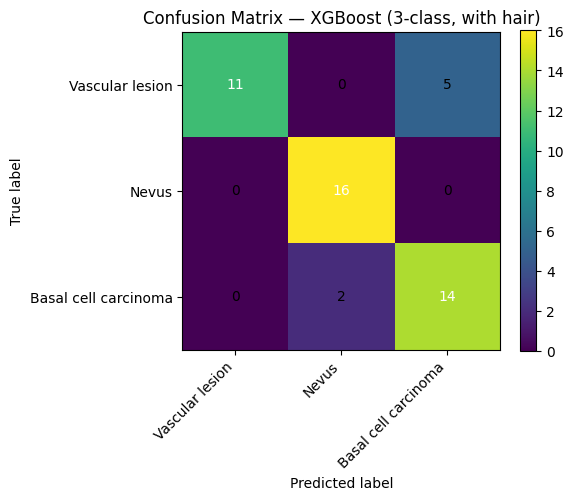

In [ ]:
#confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — XGBoost (3-class, with hair)")
plt.colorbar()

plt.xticks([0, 1, 2], class_names, rotation=45, ha="right")
plt.yticks([0, 1, 2], class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

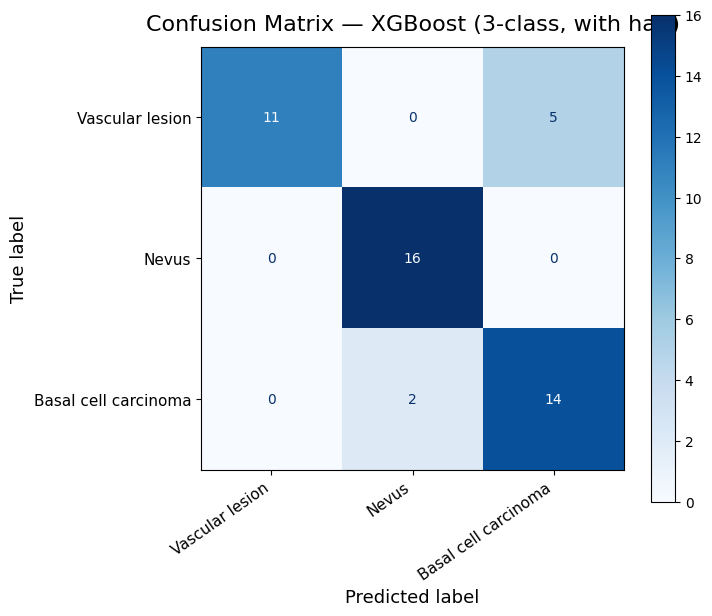

In [ ]:
#better looking confusion matrix (counts)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7.5, 6.5))  # bigger figure

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",       # integer counts
    colorbar=True
)

ax.set_title("Confusion Matrix — XGBoost (3-class, with hair)", fontsize=16, pad=12)
ax.set_xlabel("Predicted label", fontsize=13)
ax.set_ylabel("True label", fontsize=13)

#make tick labels readable
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=11)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=11)

#make cells square-ish
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

ROC-AUC macro (OvR): 0.9759


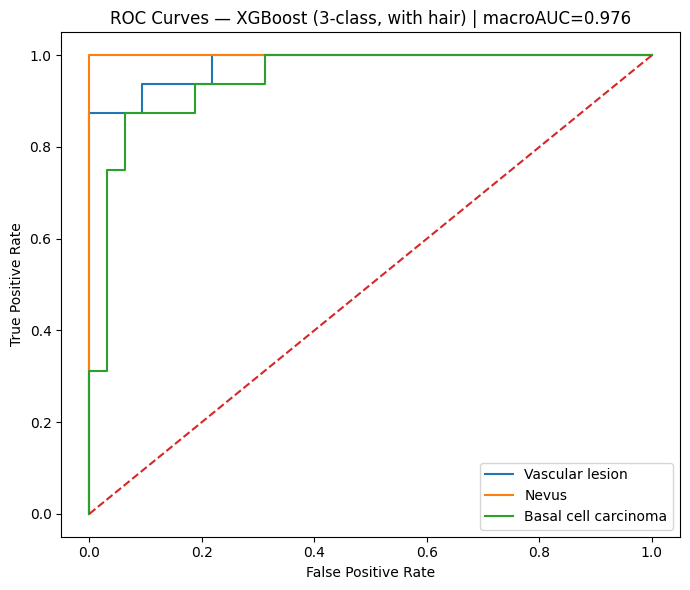

In [ ]:
#ROC-AUC (macro OvR) + ROC curves

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

auc_macro = roc_auc_score(
    y_test_bin,
    y_proba,
    average="macro",
    multi_class="ovr"
)

print("ROC-AUC macro (OvR):", round(auc_macro, 4))

plt.figure(figsize=(7, 6))

for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=cname)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves — XGBoost (3-class, with hair) | macroAUC={auc_macro:.3f}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

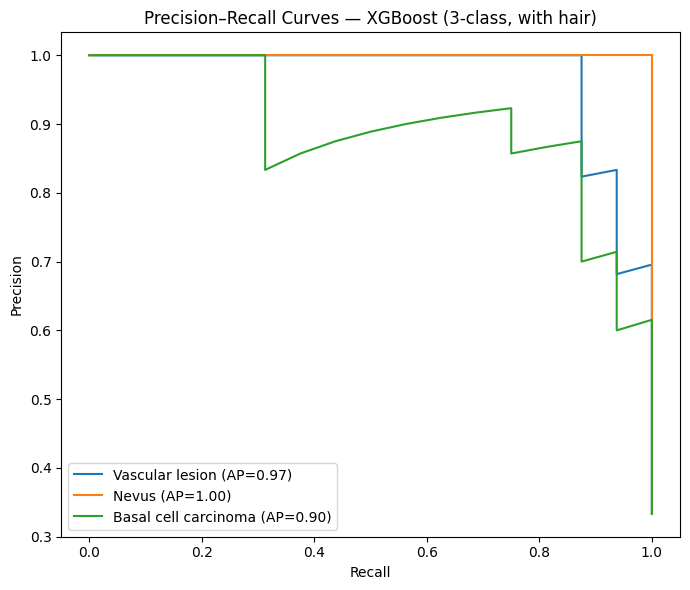

In [ ]:
#precision–recall curves (OvR)

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for i, cname in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, label=f"{cname} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — XGBoost (3-class, with hair)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [ ]:
#feature importance (gain) + table + plot

import pandas as pd
import matplotlib.pyplot as plt

xgb_model = best_model.named_steps["xgb"]
feature_names = X_train.columns.tolist()

booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type="gain")

mapped_scores = {}
for k, v in gain_scores.items():
    if k.startswith("f"):
        idx = int(k[1:])
        if idx < len(feature_names):
            mapped_scores[feature_names[idx]] = v

imp_df = (
    pd.DataFrame({
        "feature": list(mapped_scores.keys()),
        "gain": list(mapped_scores.values())
    })
    .sort_values("gain", ascending=False)
)

print("Top 20 features (gain):")
display(imp_df.head(20))

Top 20 features (gain):


,feature,gain
10,hist_feature_7,11.568157
11,hist_feature_8,7.444342
9,hist_feature_6,6.059660
8,hist_feature_5,5.462547
41,hist_feature_38,3.612879
39,hist_feature_36,2.442506
40,hist_feature_37,2.371216
42,hist_feature_39,2.316568
38,hist_feature_35,2.079517
7,hist_feature_4,2.038100


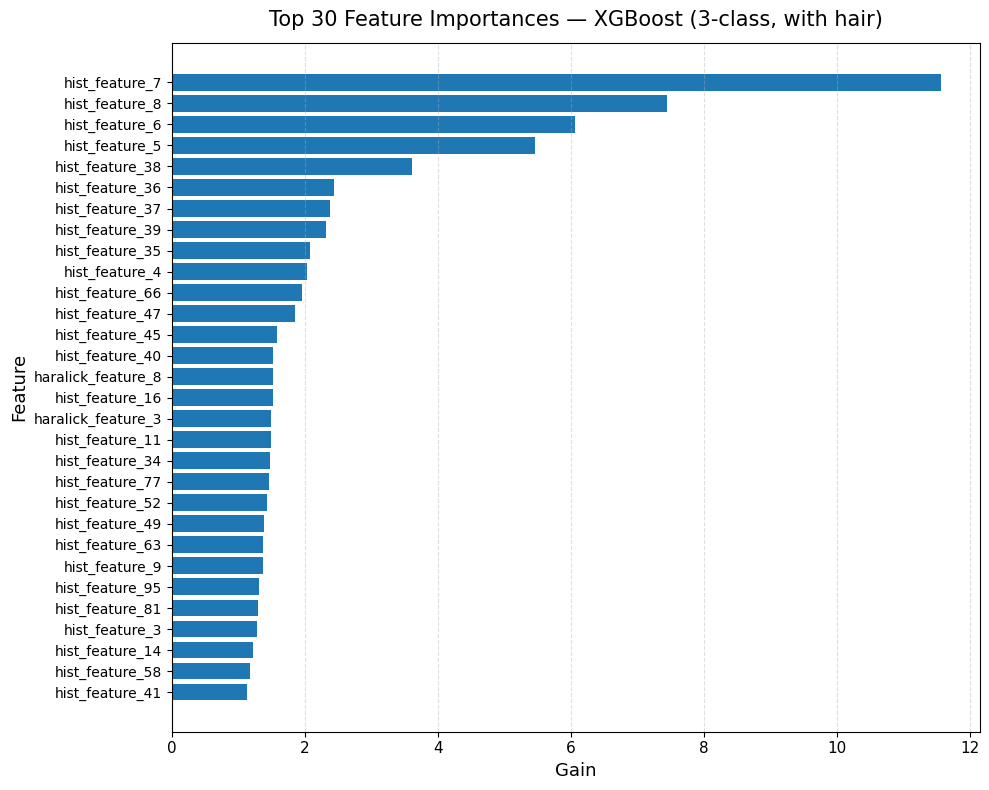

In [ ]:
#top-30 feature importance plot

top_n = 30
top_imp = imp_df.head(top_n).iloc[::-1]  #reverse for barh

plt.figure(figsize=(10, 8))

plt.barh(
    top_imp["feature"],
    top_imp["gain"],
    color="#1f77b4"
)

plt.xlabel("Gain", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.title("Top 30 Feature Importances — XGBoost (3-class, with hair)", fontsize=15, pad=12)

#subtle grid like your 2-class plot
plt.grid(axis="x", linestyle="--", alpha=0.4)

#make text readable
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
#save predictions + probabilities

import pandas as pd
import os

results_df = X_test.copy()
results_df["true_label"] = y_test.values
results_df["pred_label"] = y_pred
results_df[["prob_vascular", "prob_nevus", "prob_bcc"]] = y_proba

save_path = "/content/drive/MyDrive/CAPSTONE PROJECT/xgb_3class_with_hair_results.csv"
results_df.to_csv(save_path, index=False)

print("Saved results to:", save_path)

Saved results to: /content/drive/MyDrive/CAPSTONE PROJECT/xgb_3class_with_hair_results.csv


In [ ]:
#basic error analysis on test set predictions

results_df["correct"] = results_df["true_label"] == results_df["pred_label"]

print("Correct vs incorrect predictions:")
print(results_df["correct"].value_counts())

print("\nMisclassified samples (first 10):")
results_df.loc[~results_df["correct"]].head(10)

Correct vs incorrect predictions:
correct
True     41
False     7
Name: count, dtype: int64

Misclassified samples (first 10):


,avg_r,avg_g,avg_b,hist_feature_0,hist_feature_1,hist_feature_2,hist_feature_3,hist_feature_4,hist_feature_5,hist_feature_6,...,haralick_feature_9,haralick_feature_10,haralick_feature_11,haralick_feature_12,true_label,pred_label,prob_vascular,prob_nevus,prob_bcc,correct
18,203.781219,179.247785,208.150415,0.0,0.0,0.0,0.0,1.0,2.0,4.0,...,0.000823,2.702281,-0.397409,0.994713,0,2,0.363988,0.004986,0.631026,False
24,199.743007,163.117859,165.537437,0.0,6.0,40.0,97.0,97.0,127.0,160.0,...,0.001059,2.549246,-0.475098,0.998360,0,2,0.492610,0.000504,0.506886,False
25,175.492115,136.511933,148.193356,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000856,2.950328,-0.291171,0.976837,0,2,0.072492,0.115908,0.811600,False
28,194.473022,163.538607,159.655856,0.0,17.0,300.0,469.0,413.0,402.0,297.0,...,0.000856,2.801841,-0.370936,0.991998,0,2,0.020612,0.001550,0.977837,False
31,188.145670,119.748767,129.152411,0.0,0.0,0.0,2.0,24.0,202.0,591.0,...,0.000575,3.527868,-0.293903,0.985448,0,2,0.291507,0.135768,0.572725,False
40,164.222952,137.395337,136.919037,1.0,1572.0,6420.0,4680.0,4129.0,6757.0,6893.0,...,0.000852,2.749940,-0.525231,0.999696,2,1,0.111305,0.880618,0.008077,False
45,210.008981,152.667700,160.465244,70.0,522.0,1238.0,2046.0,2926.0,3954.0,5014.0,...,0.000466,3.698681,-0.414966,0.998852,2,1,0.054024,0.521938,0.424038,False


In [ ]:
#where the model is getting confused

confusion_breakdown = (
    results_df
    .loc[~results_df["correct"], ["true_label", "pred_label"]]
    .value_counts()
    .reset_index(name="count")
)

confusion_breakdown

,true_label,pred_label,count
0,0,2,5
1,2,1,2


In [ ]:
#per-class precision, recall, f1

from sklearn.metrics import classification_report

class_names = [
    "Vascular lesion",
    "Nevus",
    "Basal cell carcinoma"
]

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_df = (
    pd.DataFrame(report)
    .transpose()
    .loc[class_names, ["precision", "recall", "f1-score"]]
    .round(4)
)

per_class_df

,precision,recall,f1-score
Vascular lesion,1.0000,0.6875,0.8148
Nevus,0.8889,1.0000,0.9412
Basal cell carcinoma,0.7368,0.8750,0.8000


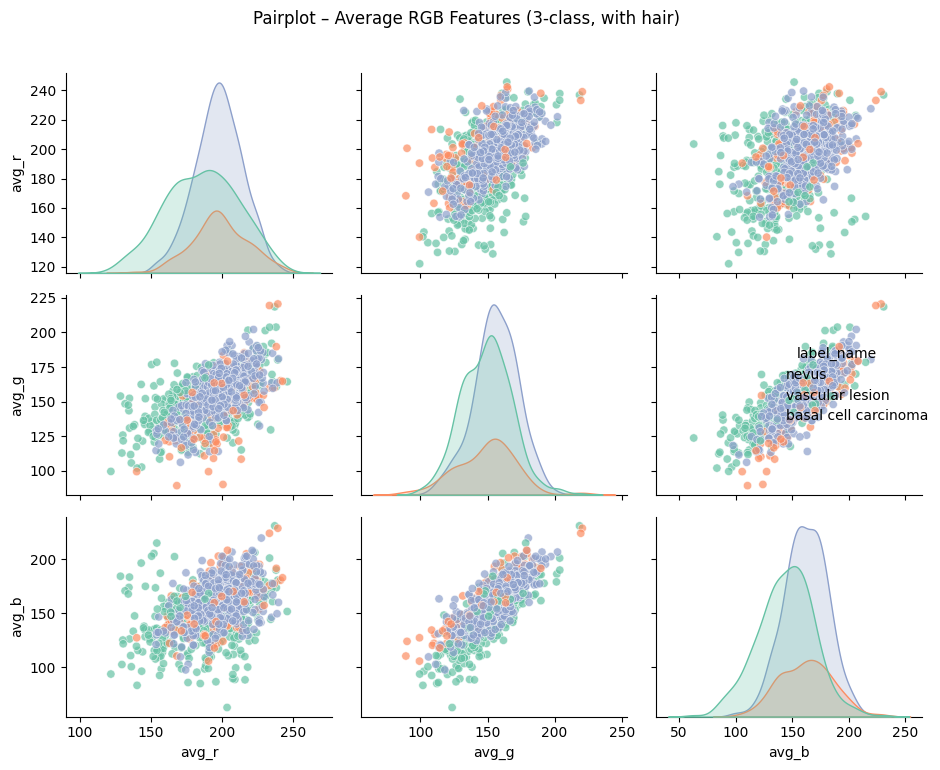

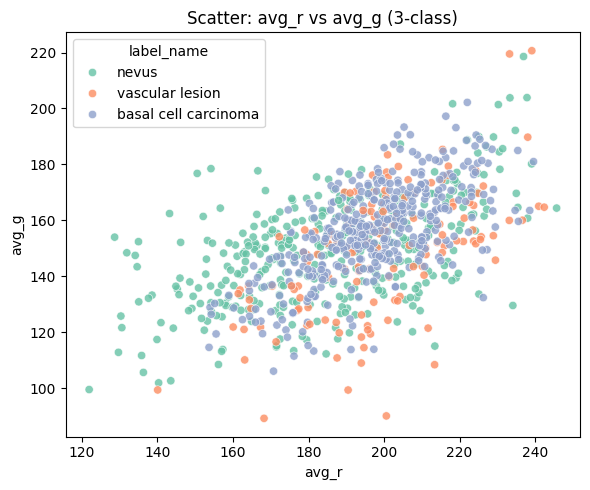

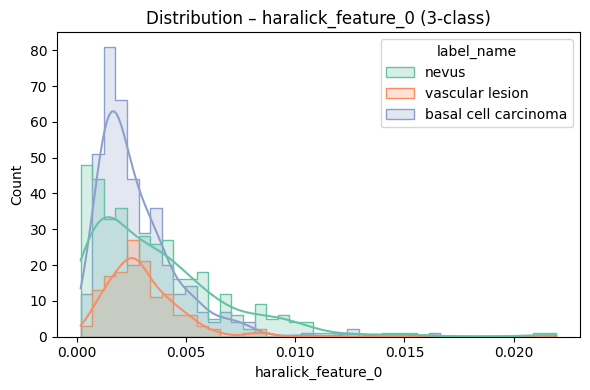

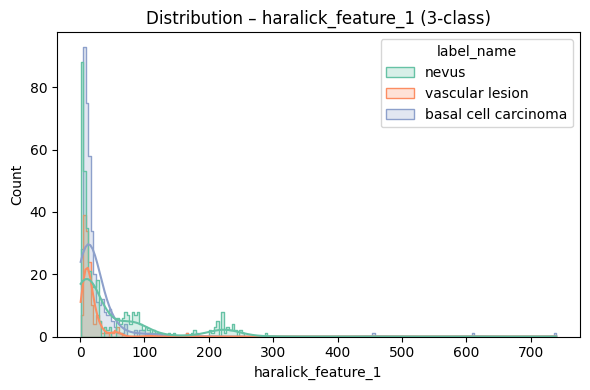

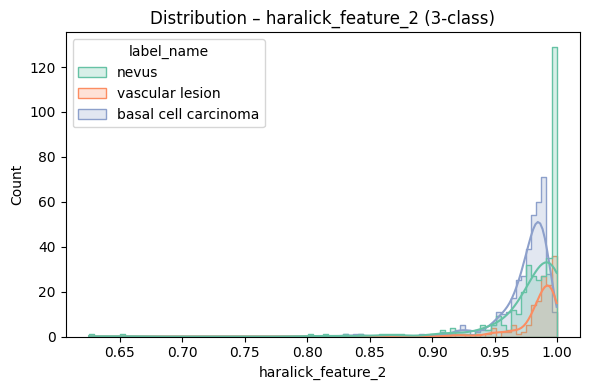

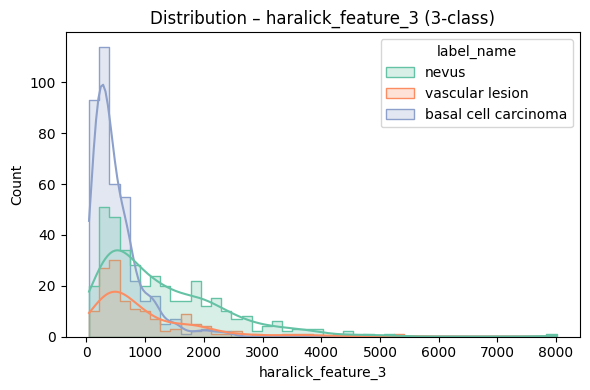

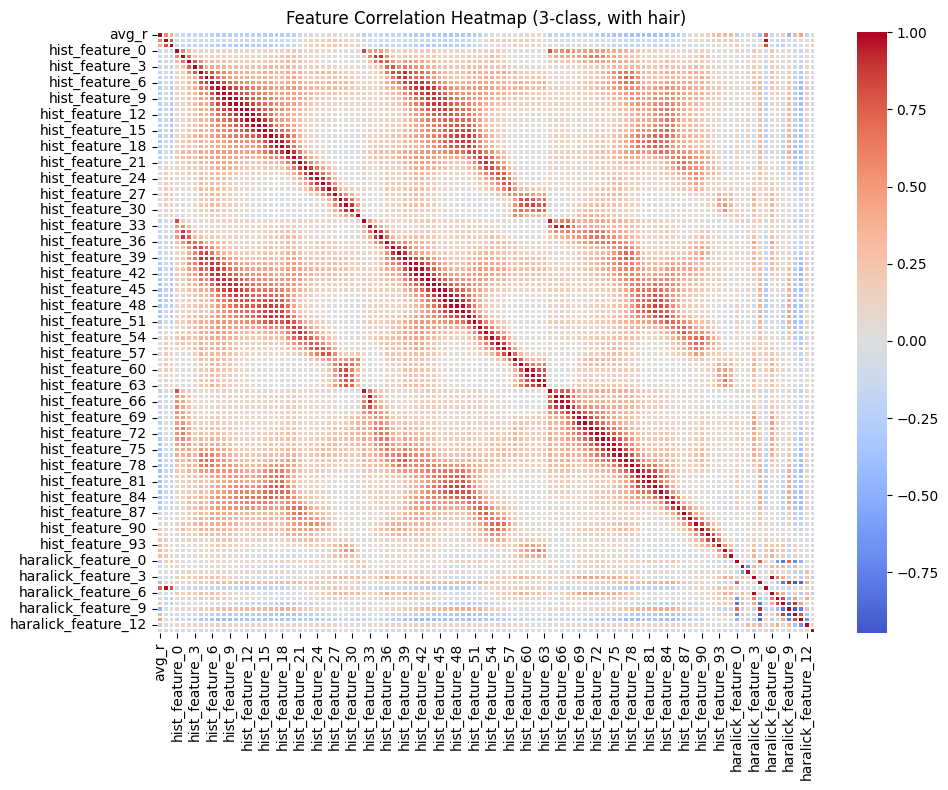

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

#combine train + test for visualization only
df_vis = pd.concat([df_train, df_test], axis=0).copy()

#map numeric labels -> class names (3-class, WITH hair)
label_map = {
    0: "vascular lesion",
    1: "nevus",
    2: "basal cell carcinoma"
}
df_vis["label_name"] = df_vis["label"].map(label_map)

#make sure results directory exists
RESULTS_DIR = "/content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair"
os.makedirs(RESULTS_DIR, exist_ok=True)

#1)Pairplot - Average RGB features
rgb_cols = [c for c in df_vis.columns if "avg_" in c.lower()][:3]

if len(rgb_cols) >= 2:
    sns.pairplot(
        df_vis,
        vars=rgb_cols,
        hue="label_name",
        diag_kind="kde",
        palette="Set2",
        plot_kws={"alpha": 0.7}
    )
    plt.suptitle("Pairplot – Average RGB Features (3-class, with hair)", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "pairplot_rgb_3class.png"), dpi=150)
    plt.show()


#2)Scatter example - R vs G (or first two avg channels)
if len(rgb_cols) >= 2:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df_vis,
        x=rgb_cols[0],
        y=rgb_cols[1],
        hue="label_name",
        palette="Set2",
        alpha=0.8
    )
    plt.title(f"Scatter: {rgb_cols[0]} vs {rgb_cols[1]} (3-class)")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "scatter_rgb_3class.png"), dpi=150)
    plt.show()


#3)Histogram distributions - Haralick texture features
tex_cols = [c for c in df_vis.columns if "haralick" in c.lower()][:4]

for col in tex_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_vis,
        x=col,
        hue="label_name",
        kde=True,
        element="step",
        palette="Set2"
    )
    plt.title(f"Distribution – {col} (3-class)")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"hist_{col}_3class.png"), dpi=150)
    plt.show()


#4)Correlation heatmap - numeric features only
num_cols = df_vis.select_dtypes(include="number").columns

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_vis[num_cols].corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)
plt.title("Feature Correlation Heatmap (3-class, with hair)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_heatmap_3class.png"), dpi=150)
plt.show()

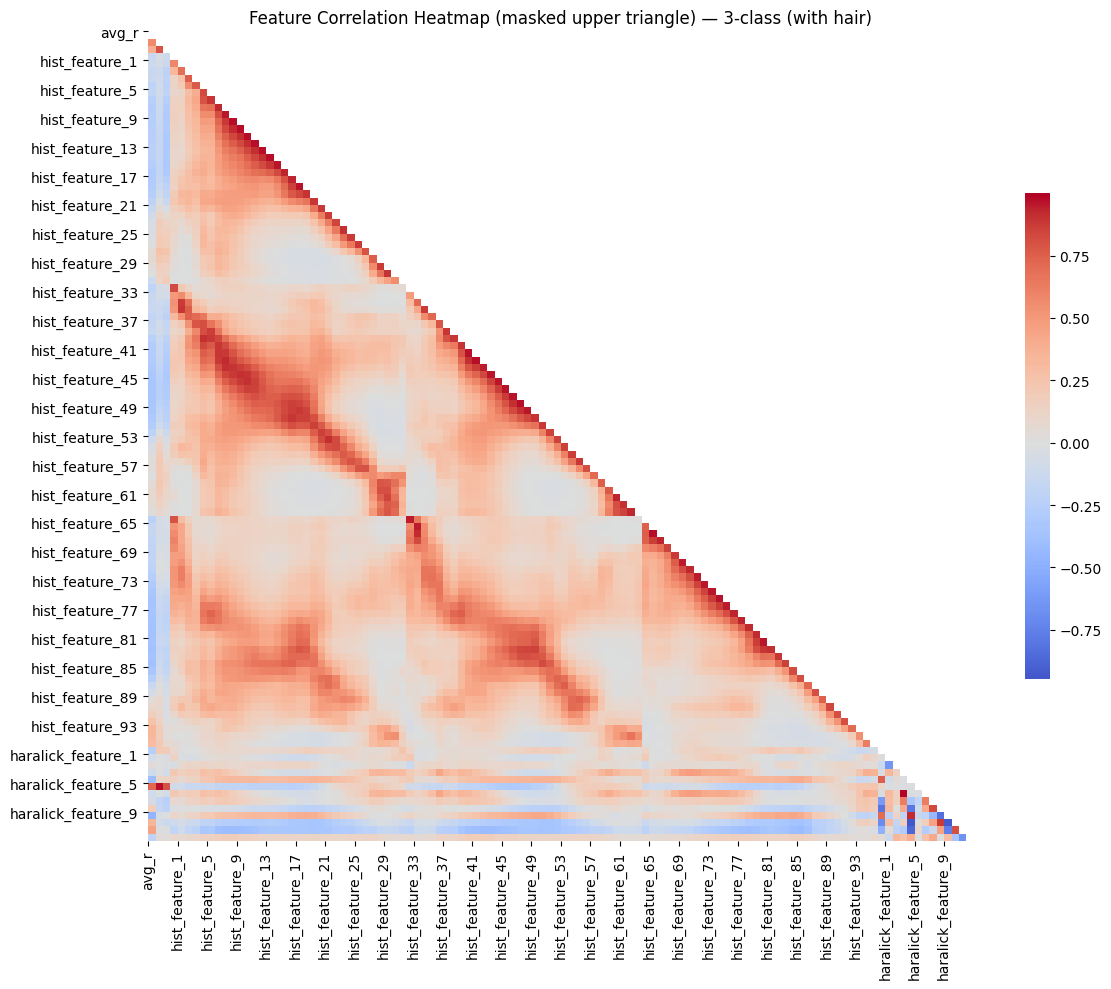

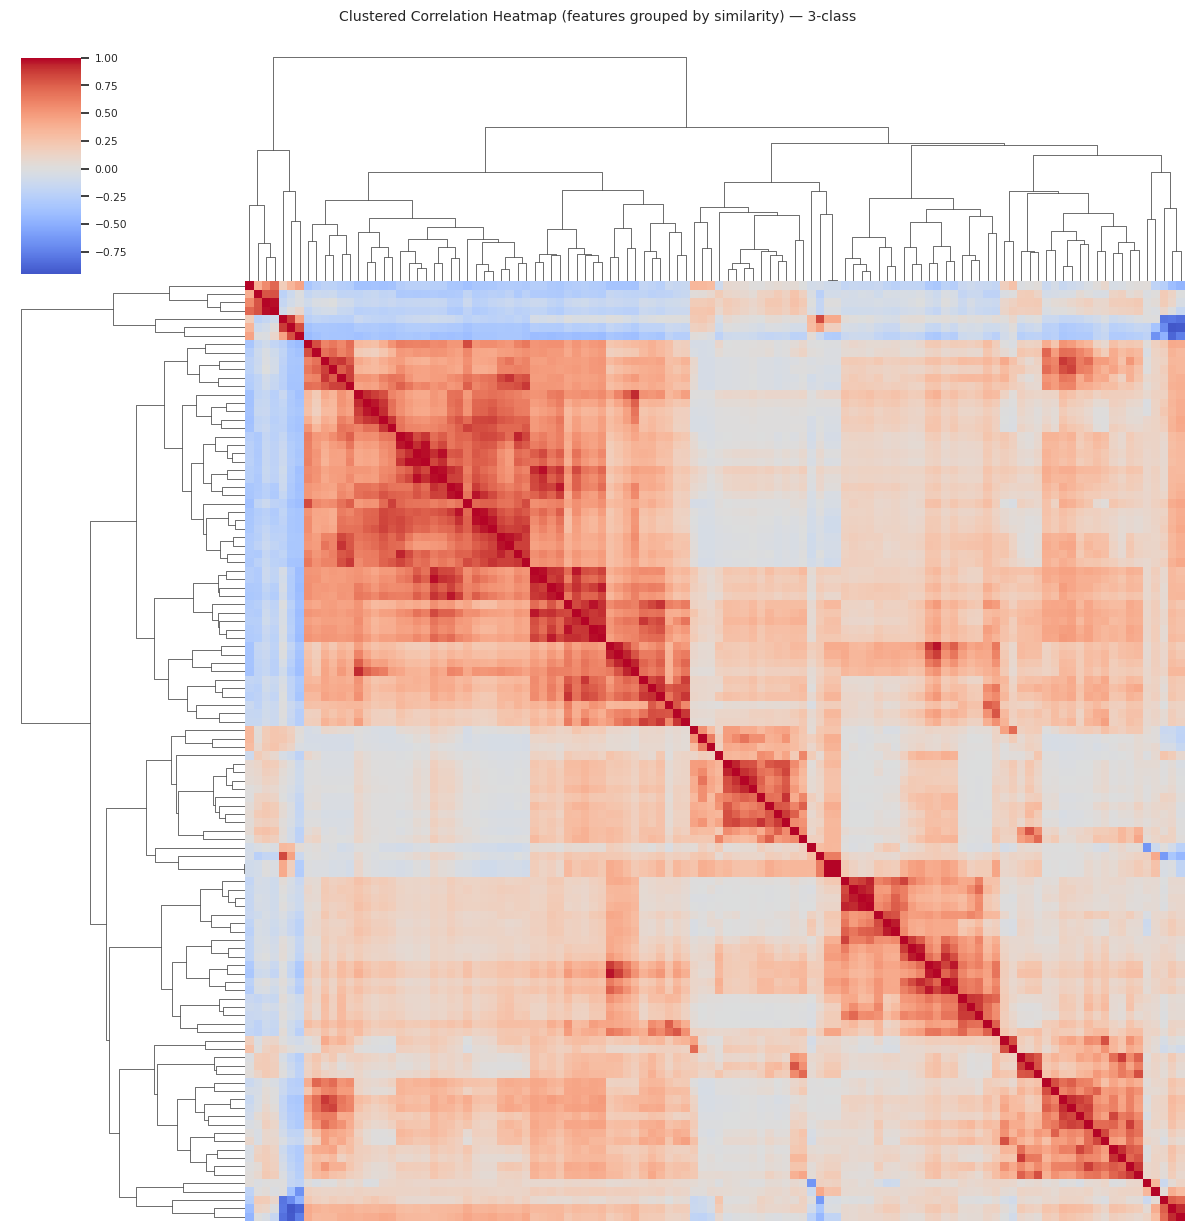

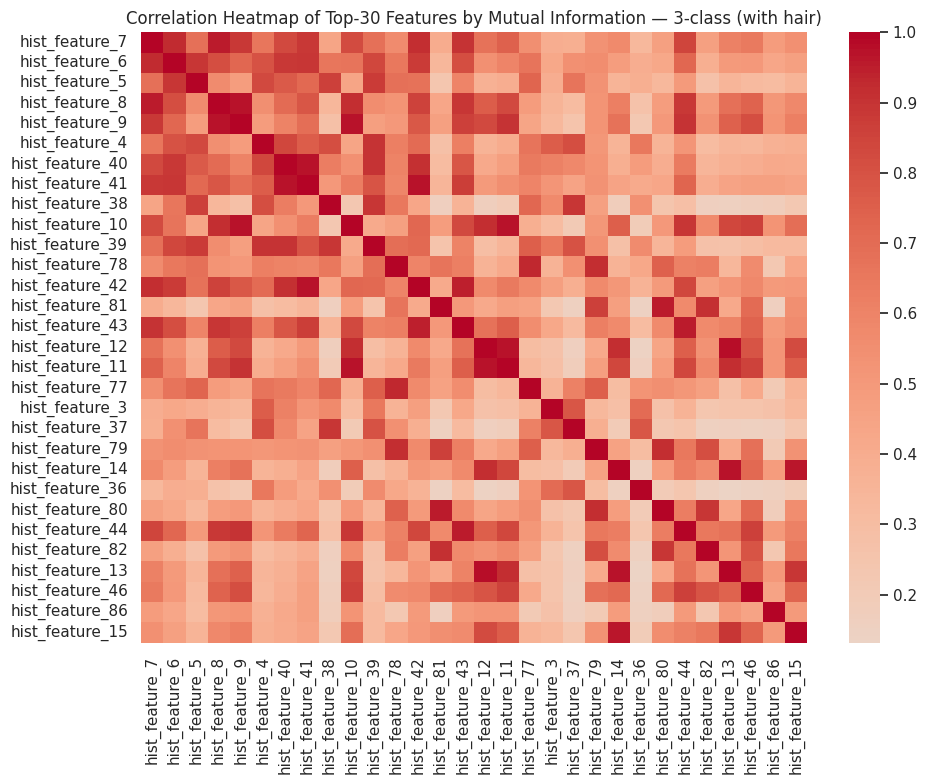

Saved MI ranking to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/feature_mutual_information_3class.csv


In [ ]:
#clean correlation visuals (3-class, with hair)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.feature_selection import mutual_info_classif

#build a single dataframe with numeric features + numeric label
df_vis = pd.concat([df_train, df_test], axis=0, ignore_index=True).copy()

#make sure RESULTS_DIR exists
os.makedirs(RESULTS_DIR, exist_ok=True)

#ensure label is numeric (0/1/2)
#(your df_train/df_test label SHOULD already be numeric after the remap)
#but this handles the case where label might be strings

if df_vis["label"].dtype == "object":
    df_vis["label"] = df_vis["label"].replace({
        "vascular lesion": 0,
        "nevus": 1,
        "basal cell carcinoma": 2
    }).astype(int)
else:
    df_vis["label"] = df_vis["label"].astype(int)

num_cols = df_vis.select_dtypes(include="number").columns.tolist()
feat_cols = [c for c in num_cols if c != "label"]


#A) masked upper-triangle heatmap (sparse ticks)

corr = df_vis[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.6},
    xticklabels=False,
    yticklabels=False
)

plt.title("Feature Correlation Heatmap (masked upper triangle) — 3-class (with hair)")

#show every Nth tick to reduce clutter
N = max(1, len(feat_cols) // 25)

ax.set_xticks(np.arange(0, len(feat_cols), N))
ax.set_yticks(np.arange(0, len(feat_cols), N))

ax.set_xticklabels([feat_cols[i] for i in range(0, len(feat_cols), N)], rotation=90)
ax.set_yticklabels([feat_cols[i] for i in range(0, len(feat_cols), N)], rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_heatmap_masked_3class.png"), dpi=150)
plt.show()

#B)clustered heatmap (groups redundant features)

sns.set(font_scale=0.7)

g = sns.clustermap(
    corr,
    cmap="coolwarm",
    center=0,
    figsize=(12, 12),
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"shrink": 0.6}
)

g.fig.suptitle("Clustered Correlation Heatmap (features grouped by similarity) — 3-class", y=1.02)
g.savefig(os.path.join(RESULTS_DIR, "correlation_clustermap_3class.png"), dpi=150)
plt.show()

sns.set(font_scale=1.0)

#C)top-30 features by relevance to label (mutual information)

X_mi = df_vis[feat_cols].copy()
y_mi = df_vis["label"].copy()

#MI can break if there are NaNs, so we fill just for this step
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))

mi = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42,
    discrete_features=False
)

mi_df = (
    pd.DataFrame({"feature": feat_cols, "MI": mi})
    .sort_values("MI", ascending=False)
)

top_k = mi_df.head(30)["feature"].tolist() if len(mi_df) > 30 else mi_df["feature"].tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_vis[top_k].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Top-30 Features by Mutual Information — 3-class (with hair)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_top30_by_MI_3class.png"), dpi=150)
plt.show()

#saving the MI ranking for your report
mi_df.to_csv(os.path.join(RESULTS_DIR, "feature_mutual_information_3class.csv"), index=False)

print("Saved MI ranking to:", os.path.join(RESULTS_DIR, "feature_mutual_information_3class.csv"))

=== 10 Least Important Features (by gain) ===


,feature,gain
93,hist_feature_90,0.362037
59,hist_feature_56,0.395387
72,hist_feature_69,0.399719
88,hist_feature_85,0.416994
73,hist_feature_70,0.417947
36,hist_feature_33,0.438037
89,hist_feature_86,0.444374
92,hist_feature_89,0.450318
78,hist_feature_75,0.462502
90,hist_feature_87,0.480098


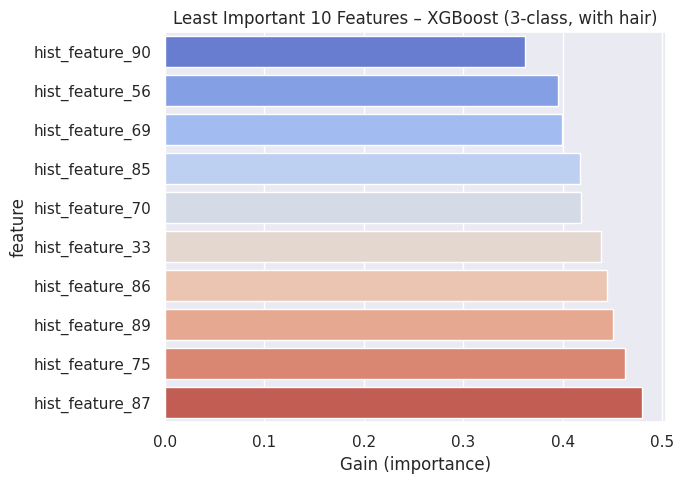

In [ ]:
#Least Important Features — XGBoost (3-class, with hair)

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

#extract trained XGBoost model from pipeline
fitted_xgb = best_model.named_steps["xgb"]

#get feature importance (gain)
booster = fitted_xgb.get_booster()
importance_dict = booster.get_score(importance_type="gain")

#convert to DataFrame
imp_df = (
    pd.DataFrame(importance_dict.items(), columns=["feature", "gain"])
    .sort_values(by="gain", ascending=False)
)

#map f0, f1, ... back to actual feature names
feature_names = X_train.columns.tolist()

if all(f.startswith("f") for f in imp_df["feature"]):
    def idx_to_name(f):
        try:
            idx = int(f[1:])
            return feature_names[idx] if idx < len(feature_names) else f
        except:
            return f

    imp_df["feature"] = imp_df["feature"].apply(idx_to_name)

#save full importance ranking
imp_df.to_csv(
    os.path.join(RESULTS_DIR, "xgb_feature_importances_full_3class.csv"),
    index=False
)

#bottom 10 least important features
least_10 = imp_df.tail(10).sort_values(by="gain", ascending=True)

print("=== 10 Least Important Features (by gain) ===")
display(least_10)

#plot
plt.figure(figsize=(7, 5))
sns.barplot(
    data=least_10,
    x="gain",
    y="feature",
    palette="coolwarm"
)
plt.title("Least Important 10 Features – XGBoost (3-class, with hair)")
plt.xlabel("Gain (importance)")
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "least_important_features_3class.png"),
    dpi=150
)
plt.show()

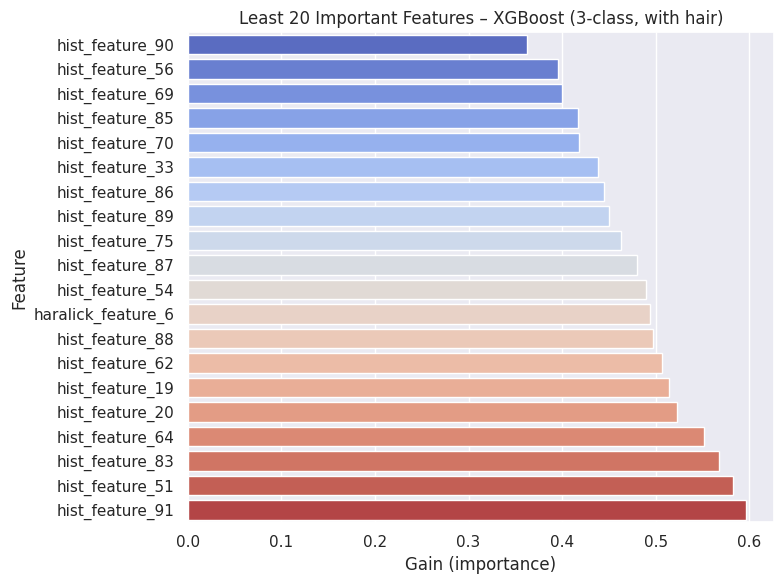

Saved plot to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/least_20_feature_importances_3class.png


In [ ]:
# ====================== Plot 20 Least Important Features ======================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# read importance file
imp_path = os.path.join(RESULTS_DIR, "xgb_feature_importances_full_3class.csv")
imp_df = pd.read_csv(imp_path)

# ensure sorted ascending by importance (gain)
imp_df = imp_df.sort_values(by="gain", ascending=True)

# bottom 20 least important features
least_20 = imp_df.head(20)

# plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=least_20,
    x="gain",
    y="feature",
    palette="coolwarm"
)

plt.title("Least 20 Important Features – XGBoost (3-class, with hair)")
plt.xlabel("Gain (importance)")
plt.ylabel("Feature")
plt.tight_layout()

# save figure
out_path = os.path.join(RESULTS_DIR, "least_20_feature_importances_3class.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Saved plot to: {out_path}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


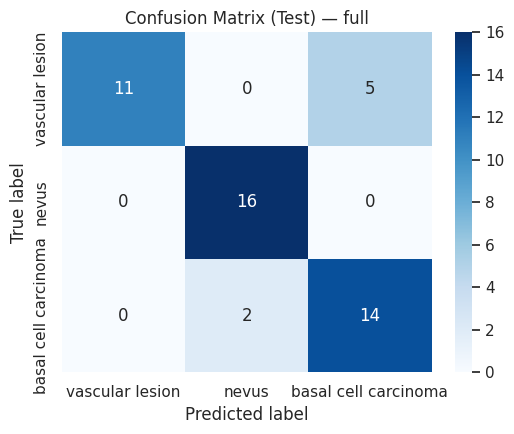

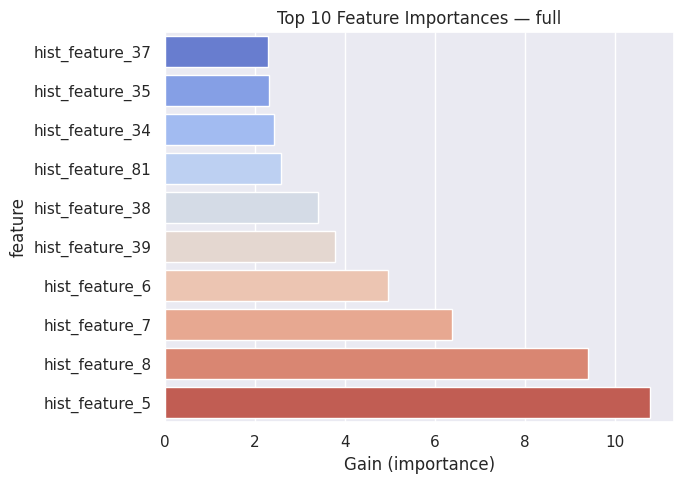

Fitting 5 folds for each of 40 candidates, totalling 200 fits


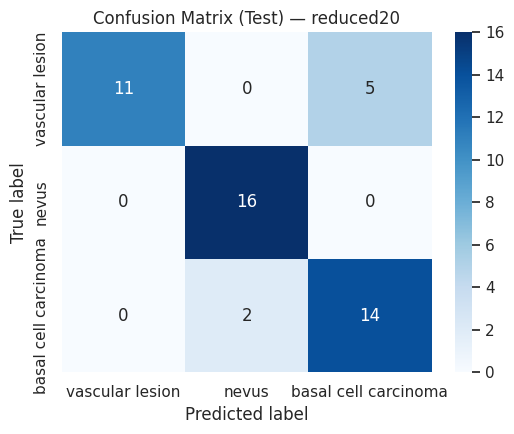

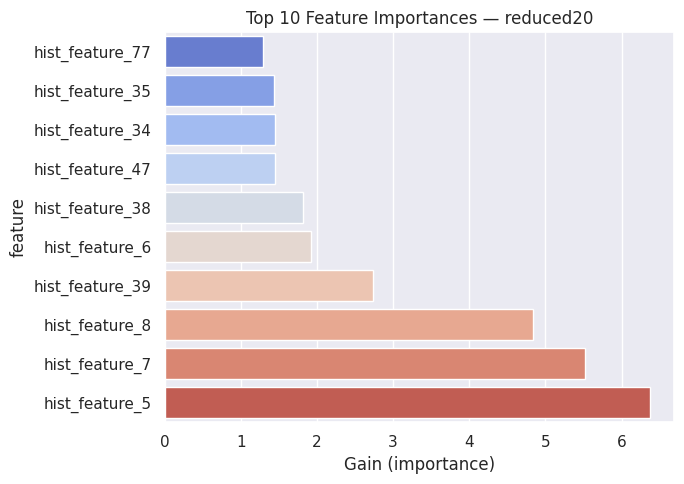

,Model,Features,Validation Acc,Test Acc
0,XGBoost (Full),112,0.884393,0.854167
1,XGBoost (-20 feats),92,0.890173,0.854167


Saved comparison to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/xgb_full_vs_reduced20_summary.csv


In [ ]:
# ====================== XGB: Full vs Reduced (drop 20 least important) ======================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

# ---- 3-class setup
CLASS_NAMES = ["vascular lesion", "nevus", "basal cell carcinoma"]
LABELS = [0, 1, 2]

# ------------------------------------------------------------------
# Confusion matrix plot
def plot_confmat(y_true, y_pred, outpath, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=True
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.show()
    plt.close()

# ------------------------------------------------------------------
# Top-10 feature importances
def plot_top10_importances(fitted_xgb, feat_names, outpath, title):
    booster = fitted_xgb.get_booster()
    score = booster.get_score(importance_type="gain")

    imp_df = (
        pd.DataFrame(score.items(), columns=["feature", "gain"])
        .sort_values("gain", ascending=False)
    )

    # map f0,f1,... → real column names
    if all(f.startswith("f") for f in imp_df["feature"]):
        def idx_to_name(f):
            try:
                i = int(f[1:])
                return feat_names[i] if i < len(feat_names) else f
            except:
                return f
        imp_df["feature"] = imp_df["feature"].apply(idx_to_name)

    # save full importance list
    imp_df.to_csv(
        os.path.join(os.path.dirname(outpath), "feature_importances_full.csv"),
        index=False
    )

    top10 = imp_df.head(10).iloc[::-1]

    plt.figure(figsize=(7, 5))
    sns.barplot(data=top10, x="gain", y="feature", palette="coolwarm")
    plt.xlabel("Gain (importance)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.show()
    plt.close()

    return imp_df

# ------------------------------------------------------------------
# Train + evaluate block
def train_eval_block(X_all, y_all, X_test_all, y_test_all, tag, drop_feats=None):
    out_dir = os.path.join(RESULTS_DIR, f"xgb_{tag}")
    os.makedirs(out_dir, exist_ok=True)

    if drop_feats is not None:
        X_all = X_all.drop(columns=drop_feats, errors="ignore")
        X_test_all = X_test_all.drop(columns=drop_feats, errors="ignore")

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_all, y_all,
        test_size=0.20,
        stratify=y_all,
        random_state=SEED
    )

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=40,
        scoring="f1_macro",
        n_jobs=-1,
        cv=cv,
        random_state=SEED,
        verbose=1
    )

    search.fit(X_tr, y_tr)
    best_model = search.best_estimator_

    with open(os.path.join(out_dir, "best_params.json"), "w") as f:
        json.dump(search.best_params_, f, indent=2)

    # ---- validation
    y_val_pred = best_model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_report = classification_report(
        y_val, y_val_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    with open(os.path.join(out_dir, "validation_report.txt"), "w") as f:
        f.write(val_report)
        f.write(f"\nValidation Accuracy: {val_acc:.4f}\n")

    # ---- test
    y_te_pred = best_model.predict(X_test_all)
    te_acc = accuracy_score(y_test_all, y_te_pred)
    te_report = classification_report(
        y_test_all, y_te_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    with open(os.path.join(out_dir, "test_report.txt"), "w") as f:
        f.write(te_report)
        f.write(f"\nTest Accuracy: {te_acc:.4f}\n")

    plot_confmat(
        y_test_all,
        y_te_pred,
        os.path.join(out_dir, "confusion_matrix.png"),
        title=f"Confusion Matrix (Test) — {tag}"
    )

    imp_df = plot_top10_importances(
        best_model.named_steps["xgb"],
        X_all.columns.tolist(),
        os.path.join(out_dir, "top10_feature_importances.png"),
        title=f"Top 10 Feature Importances — {tag}"
    )

    imp_df.sort_values("gain", ascending=True).to_csv(
        os.path.join(out_dir, "feature_importances_sorted_asc.csv"),
        index=False
    )

    return {
        "model": best_model,
        "val_acc": val_acc,
        "te_acc": te_acc,
        "importance_df": imp_df
    }

# ====================== RUN ======================

# 1) FULL
xgb_full = train_eval_block(X_train, y_train, X_test, y_test, tag="full")

# 2) REDUCED (drop 20 least important)
least_20 = (
    xgb_full["importance_df"]
    .sort_values("gain", ascending=True)
    .head(20)["feature"]
    .tolist()
)

pd.DataFrame({"feature": least_20}).to_csv(
    os.path.join(RESULTS_DIR, "xgb_least_20_features.csv"),
    index=False
)

xgb_reduced20 = train_eval_block(
    X_train, y_train, X_test, y_test,
    tag="reduced20",
    drop_feats=least_20
)

# 3) Summary table
cmp = pd.DataFrame([
    {
        "Model": "XGBoost (Full)",
        "Features": X_train.shape[1],
        "Validation Acc": xgb_full["val_acc"],
        "Test Acc": xgb_full["te_acc"]
    },
    {
        "Model": "XGBoost (-20 feats)",
        "Features": X_train.shape[1] - len(least_20),
        "Validation Acc": xgb_reduced20["val_acc"],
        "Test Acc": xgb_reduced20["te_acc"]
    }
])

cmp_path = os.path.join(RESULTS_DIR, "xgb_full_vs_reduced20_summary.csv")
cmp.to_csv(cmp_path, index=False)
display(cmp)
print("Saved comparison to:", cmp_path)


Original feature count: 112
Reduced feature count : 92
Fitting 5 folds for each of 40 candidates, totalling 200 fits

BEST PARAMETERS:
{
  "xgb__subsample": 0.8,
  "xgb__reg_lambda": 1.0,
  "xgb__reg_alpha": 0.1,
  "xgb__n_estimators": 400,
  "xgb__max_depth": 5,
  "xgb__learning_rate": 0.05,
  "xgb__colsample_bytree": 1.0
}
Best CV F1_macro: 0.8282

VALIDATION REPORT:
                       precision    recall  f1-score   support

     vascular lesion       0.81      0.68      0.74        25
               nevus       0.93      0.89      0.91        72
basal cell carcinoma       0.88      0.96      0.92        76

            accuracy                           0.89       173
           macro avg       0.87      0.84      0.86       173
        weighted avg       0.89      0.89      0.89       173

Validation Accuracy: 0.8902

TEST REPORT:
                       precision    recall  f1-score   support

     vascular lesion       1.00      0.69      0.81        16
               nevus  

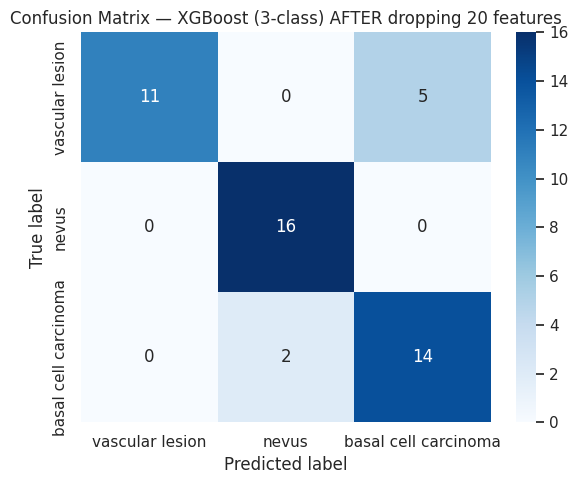

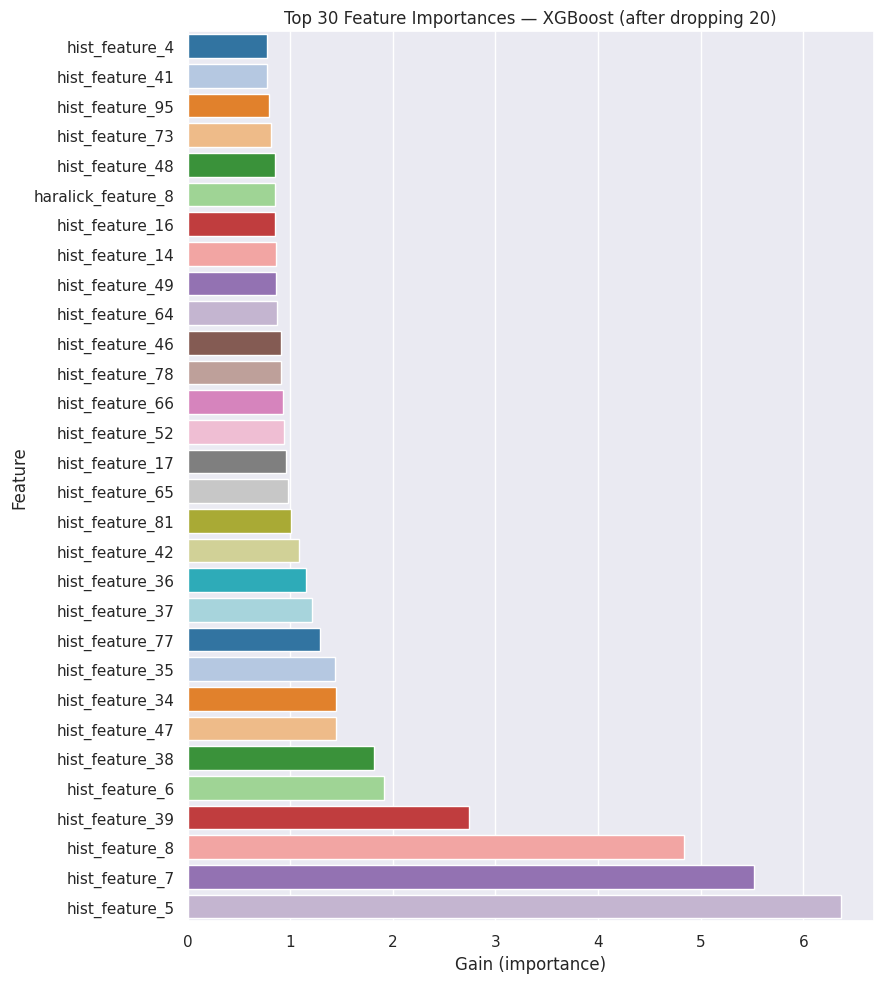


Saved results to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/xgb_after_dropping_20/xgb_3class_after_drop20_results.csv


In [ ]:
# ====================== XGB — AFTER DROPPING 20 FEATURES ======================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

CLASS_NAMES = ["vascular lesion", "nevus", "basal cell carcinoma"]
LABELS = [0, 1, 2]

def plot_confmat(y_true, y_pred, outpath, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=True
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.show()
    plt.close()

def plot_top30_importances(fitted_xgb, feature_names, outpath, title):
    booster = fitted_xgb.get_booster()
    score = booster.get_score(importance_type="gain")

    imp_df = pd.DataFrame(score.items(), columns=["feature", "gain"]).sort_values("gain", ascending=False)

    # map f0,f1,... to real column names if needed
    if len(imp_df) > 0 and all(isinstance(f, str) and f.startswith("f") for f in imp_df["feature"]):
        def idx_to_name(f):
            try:
                i = int(f[1:])
                return feature_names[i] if i < len(feature_names) else f
            except:
                return f
        imp_df["feature"] = imp_df["feature"].apply(idx_to_name)

    imp_df.to_csv(os.path.join(os.path.dirname(outpath), "feature_importances_full.csv"), index=False)

    top30 = imp_df.head(30).iloc[::-1]

    plt.figure(figsize=(9, 10))
    sns.barplot(data=top30, x="gain", y="feature", palette="tab20")
    plt.xlabel("Gain (importance)")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.show()
    plt.close()

    return imp_df

# make a folder for the reduced model
out_dir = os.path.join(RESULTS_DIR, "xgb_after_dropping_20")
os.makedirs(out_dir, exist_ok=True)

# drop the least 20 features
X_train_red = X_train.drop(columns=least_20, errors="ignore")
X_test_red  = X_test.drop(columns=least_20, errors="ignore")

print("Original feature count:", X_train.shape[1])
print("Reduced feature count :", X_train_red.shape[1])

# fixed validation split (same vibe as before)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_red, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    random_state=SEED,
    verbose=1
)

search.fit(X_tr, y_tr)

print("\nBEST PARAMETERS:")
print(json.dumps(search.best_params_, indent=2))
print("Best CV F1_macro:", round(search.best_score_, 4))

best_model_reduced = search.best_estimator_

with open(os.path.join(out_dir, "best_params.json"), "w") as f:
    json.dump(search.best_params_, f, indent=2)

# ---------------- validation metrics
y_val_pred = best_model_reduced.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

val_report = classification_report(
    y_val, y_val_pred,
    labels=LABELS,
    target_names=CLASS_NAMES,
    zero_division=0
)

print("\nVALIDATION REPORT:\n", val_report)
print("Validation Accuracy:", round(val_acc, 4))

with open(os.path.join(out_dir, "validation_report.txt"), "w") as f:
    f.write(val_report)
    f.write(f"\nValidation Accuracy: {val_acc:.6f}\n")

# ---------------- test metrics
y_test_pred = best_model_reduced.predict(X_test_red)
test_acc = accuracy_score(y_test, y_test_pred)

test_report = classification_report(
    y_test, y_test_pred,
    labels=LABELS,
    target_names=CLASS_NAMES,
    zero_division=0
)

print("\nTEST REPORT:\n", test_report)
print("Test Accuracy:", round(test_acc, 4))

with open(os.path.join(out_dir, "test_report.txt"), "w") as f:
    f.write(test_report)
    f.write(f"\nTest Accuracy: {test_acc:.6f}\n")

# confusion matrix
plot_confmat(
    y_test,
    y_test_pred,
    os.path.join(out_dir, "confusion_matrix.png"),
    title="Confusion Matrix — XGBoost (3-class) AFTER dropping 20 features"
)

# top 30 importances
fitted_xgb = best_model_reduced.named_steps["xgb"]
imp_df_reduced = plot_top30_importances(
    fitted_xgb,
    X_train_red.columns.tolist(),
    os.path.join(out_dir, "top30_feature_importances.png"),
    title="Top 30 Feature Importances — XGBoost (after dropping 20)"
)

# save predictions + probabilities (nice for error analysis / Tableau)
y_test_proba = best_model_reduced.predict_proba(X_test_red)

results_df = X_test_red.copy()
results_df["true_label"] = y_test.values if hasattr(y_test, "values") else y_test
results_df["pred_label"] = y_test_pred

results_df[["prob_vascular", "prob_nevus", "prob_bcc"]] = y_test_proba

save_path = os.path.join(out_dir, "xgb_3class_after_drop20_results.csv")
results_df.to_csv(save_path, index=False)
print("\nSaved results to:", save_path)

RGB columns used: ['avg_r', 'avg_g', 'avg_b']


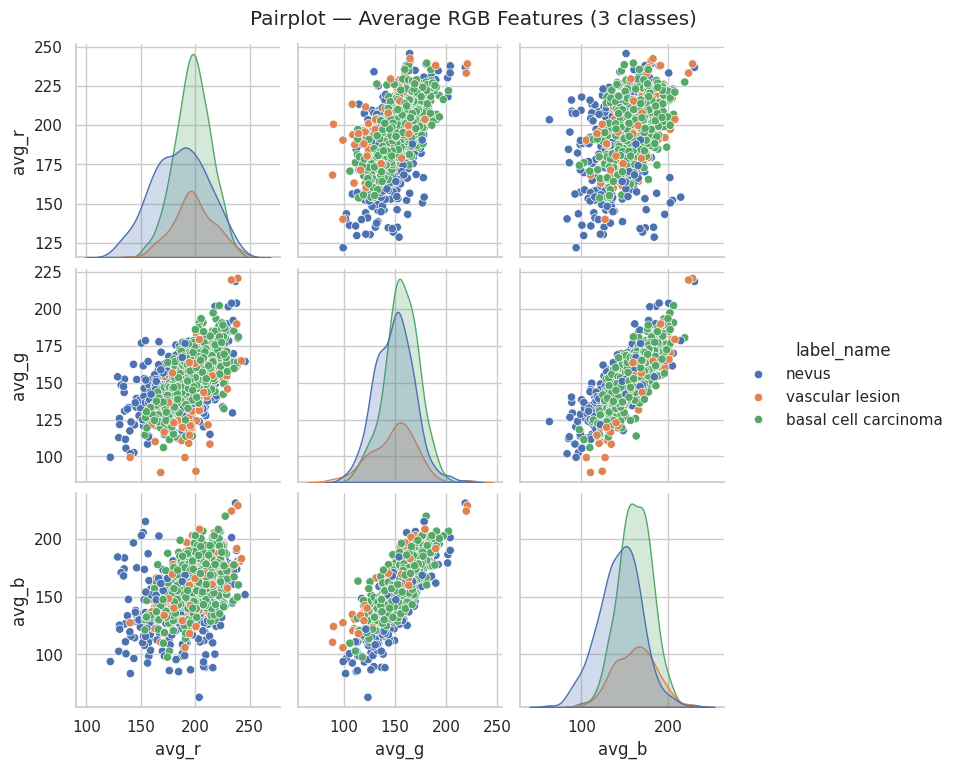

Saved pairplot to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/pairplot_rgb_3class.png


In [ ]:
# ====================== Pairplot of average RGB features (for 3 classes) ======================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# combine train + test for visualization
df_vis = pd.concat([df_train, df_test], axis=0).copy()

# map numeric labels to names (3-class)
label_map = {
    0: "vascular lesion",
    1: "nevus",
    2: "basal cell carcinoma"
}
df_vis["label_name"] = df_vis["label"].map(label_map)

# pick RGB average columns (adjust if yours are named differently)
rgb_cols = [c for c in df_vis.columns if c.lower() in ["avg_r", "avg_g", "avg_b"]]

print("RGB columns used:", rgb_cols)

# basic guard
if len(rgb_cols) == 3:
    sns.set(style="whitegrid")

    g = sns.pairplot(
        df_vis,
        vars=rgb_cols,
        hue="label_name",
        diag_kind="kde"
    )

    g.fig.suptitle("Pairplot — Average RGB Features (3 classes)", y=1.02)

    out_path = os.path.join(RESULTS_DIR, "pairplot_rgb_3class.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved pairplot to:", out_path)

else:
    print("Could not find avg_r/avg_g/avg_b in df_vis. Check your column names.")

##Permutation Importance

Permutation importance will run on:
X shape: (48, 112)
Classes in y: [np.int64(0), np.int64(1), np.int64(2)]

Quick sanity metrics (same split you’re using for PI):
Accuracy: 0.8542
                      precision    recall  f1-score   support

     vascular lesion       1.00      0.69      0.81        16
               nevus       0.89      1.00      0.94        16
basal cell carcinoma       0.74      0.88      0.80        16

            accuracy                           0.85        48
           macro avg       0.88      0.85      0.85        48
        weighted avg       0.88      0.85      0.85        48


Saved permutation importance ranking to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/permutation_importance_xgb_3class/xgb_permutation_importance_full.csv

Top 10 features by permutation importance:


,feature,pi_mean,pi_std
36,hist_feature_33,0.018082,0.009041
53,hist_feature_50,0.013561,0.011073
49,hist_feature_46,0.011301,0.011301
68,hist_feature_65,0.011301,0.011301
3,hist_feature_0,0.010663,0.017621
69,hist_feature_66,0.009106,0.014856
50,hist_feature_47,0.009041,0.011073
70,hist_feature_67,0.006846,0.014341
9,hist_feature_6,0.005324,0.018843
12,hist_feature_9,0.004585,0.013432



Bottom 10 features by permutation importance:


,feature,pi_mean,pi_std
42,hist_feature_39,-0.019608,0.018038
110,haralick_feature_11,-0.019757,0.006586
4,hist_feature_1,-0.021170,0.013501
100,haralick_feature_1,-0.021304,0.013501
8,hist_feature_5,-0.021704,0.016624
41,hist_feature_38,-0.021768,0.019278
111,haralick_feature_12,-0.021903,0.009707
11,hist_feature_8,-0.023343,0.022325
97,hist_feature_94,-0.027508,0.013770
39,hist_feature_36,-0.032019,0.022215


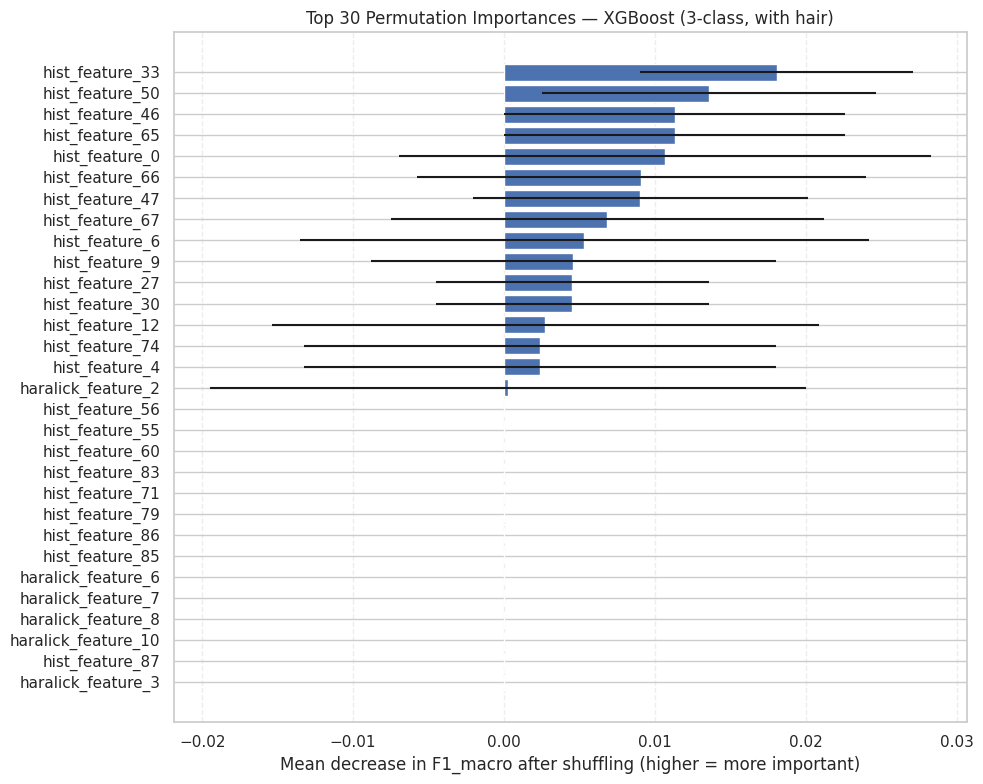

Saved top-30 plot to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/permutation_importance_xgb_3class/xgb_permutation_importance_top30.png


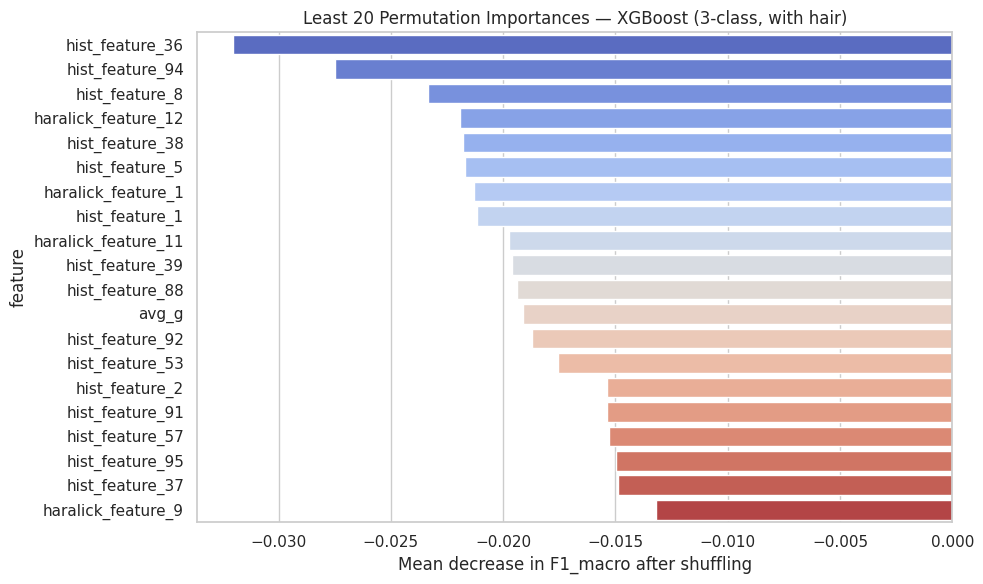

Saved least-20 plot to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/permutation_importance_xgb_3class/xgb_permutation_importance_least20.png
Saved least-20 feature list to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/permutation_importance_xgb_3class/xgb_least20_features_by_permutation.csv


In [ ]:
# ====================== Permutation Importance — XGBoost (3-class, with hair) ======================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# choose which trained model + which dataset you want to analyze
# ---------------------------------------------------------
# use your tuned 3-class model (Pipeline: imputer + xgb)
model_for_pi = best_model   # <-- change to best_model_reduced if you want the "after dropping 20" model

X_pi = X_test               # <-- use X_test_red if you're doing reduced features
y_pi = y_test

# folder for outputs
PI_DIR = os.path.join(RESULTS_DIR, "permutation_importance_xgb_3class")
os.makedirs(PI_DIR, exist_ok=True)

print("Permutation importance will run on:")
print("X shape:", X_pi.shape)
print("Classes in y:", sorted(pd.Series(y_pi).unique()))

# quick sanity: model is actually working on this X
y_pred_check = model_for_pi.predict(X_pi)
print("\nQuick sanity metrics (same split you’re using for PI):")
print("Accuracy:", round(accuracy_score(y_pi, y_pred_check), 4))
print(classification_report(y_pi, y_pred_check, target_names=["vascular lesion","nevus","basal cell carcinoma"], zero_division=0))

# ---------------------------------------------------------
# compute permutation importance
# ---------------------------------------------------------
# scoring choice:
# - f1_macro is best for 3-class because it treats each class equally
# - use fewer repeats if you want speed (like 5); more repeats = more stable ranking

pi = permutation_importance(
    model_for_pi,
    X_pi,
    y_pi,
    scoring="f1_macro",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

# build a clean dataframe
pi_df = pd.DataFrame({
    "feature": X_pi.columns,
    "pi_mean": pi.importances_mean,
    "pi_std": pi.importances_std
}).sort_values("pi_mean", ascending=False)

# save full ranking
pi_csv_path = os.path.join(PI_DIR, "xgb_permutation_importance_full.csv")
pi_df.to_csv(pi_csv_path, index=False)

print("\nSaved permutation importance ranking to:", pi_csv_path)
print("\nTop 10 features by permutation importance:")
display(pi_df.head(10))

print("\nBottom 10 features by permutation importance:")
display(pi_df.tail(10))

# ---------------------------------------------------------
# plot: top 30 permutation importances
# ---------------------------------------------------------
top_n = 30
top_df = pi_df.head(top_n).iloc[::-1]  # reverse for barh

plt.figure(figsize=(10, 8))
plt.barh(top_df["feature"], top_df["pi_mean"], xerr=top_df["pi_std"])
plt.xlabel("Mean decrease in F1_macro after shuffling (higher = more important)")
plt.title("Top 30 Permutation Importances — XGBoost (3-class, with hair)")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()

top_plot_path = os.path.join(PI_DIR, "xgb_permutation_importance_top30.png")
plt.savefig(top_plot_path, dpi=150)
plt.show()

print("Saved top-30 plot to:", top_plot_path)

# ---------------------------------------------------------
# plot: least 20 permutation importances (useful for dropping features)
# ---------------------------------------------------------
least_n = 20
least_df = pi_df.tail(least_n).sort_values("pi_mean", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=least_df, x="pi_mean", y="feature", palette="coolwarm")
plt.xlabel("Mean decrease in F1_macro after shuffling")
plt.title("Least 20 Permutation Importances — XGBoost (3-class, with hair)")
plt.tight_layout()

least_plot_path = os.path.join(PI_DIR, "xgb_permutation_importance_least20.png")
plt.savefig(least_plot_path, dpi=150)
plt.show()

print("Saved least-20 plot to:", least_plot_path)

# also save the least-20 feature list (nice for your “drop features” experiment)
least20_path = os.path.join(PI_DIR, "xgb_least20_features_by_permutation.csv")
least_df[["feature"]].to_csv(least20_path, index=False)
print("Saved least-20 feature list to:", least20_path)

##*SHAP*

In [ ]:
# ====================== SHAP Analysis — XGBoost (3-class, with hair) ======================

import shap
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#using the full 3-class XGBoost model
shap_model = best_model.named_steps["xgb"]

X_shap = X_test          # use X_test_red if analyzing reduced model
y_shap = y_test

SHAP_DIR = os.path.join(RESULTS_DIR, "shap_xgb_3class")
os.makedirs(SHAP_DIR, exist_ok=True)

print("Running SHAP on:")
print("X shape:", X_shap.shape)
print("Classes:", sorted(pd.Series(y_shap).unique()))


#initializing SHAP explainer
explainer = shap.TreeExplainer(shap_model)

#compute=ing SHAP values
#for multiclass: shap_values is a LIST, one array per class
shap_values = explainer.shap_values(X_shap)

print("Number of classes (SHAP outputs):", len(shap_values))
print("SHAP array shape (per class):", shap_values[0].shape)


#1) SHAP summary plot - class-wise
class_names = ["vascular lesion", "nevus", "basal cell carcinoma"]

for i, class_name in enumerate(class_names):
    plt.figure()
    shap.summary_plot(
        shap_values[i],
        X_shap,
        show=False
    )
    plt.title(f"SHAP Summary — {class_name} (XGBoost, 3-class)")
    out_path = os.path.join(SHAP_DIR, f"shap_summary_{class_name.replace(' ','_')}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved SHAP summary plot for {class_name} → {out_path}")


#2) SHAP global importance (mean |SHAP| across classes)

#combining absolute SHAP values across all classes
shap_abs_mean = np.mean(
    [np.abs(sv) for sv in shap_values],
    axis=(0, 1)
)

shap_global_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": shap_abs_mean
}).sort_values("mean_abs_shap", ascending=False)

#saving full SHAP ranking
shap_csv_path = os.path.join(SHAP_DIR, "shap_global_importance.csv")
shap_global_df.to_csv(shap_csv_path, index=False)

print("\nTop 10 features by global SHAP importance:")
display(shap_global_df.head(10))


#3)Plotting top 30 SHAP features (bar plot)
top_n = 30
top_shap = shap_global_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_shap["feature"], top_shap["mean_abs_shap"])
plt.xlabel("Mean |SHAP value| (impact on model output)")
plt.title("Top 30 Global SHAP Feature Importances — XGBoost (3-class)")
plt.tight_layout()

out_bar_path = os.path.join(SHAP_DIR, "shap_global_top30.png")
plt.savefig(out_bar_path, dpi=150)
plt.show()

print("Saved global SHAP bar plot →", out_bar_path)

Running SHAP on:
X shape: (48, 112)
Classes: [np.int64(0), np.int64(1), np.int64(2)]
Number of classes (SHAP outputs): 48
SHAP array shape (per class): (112, 3)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

Running SHAP on:
X_shap shape: (48, 112)
Unique y: [np.int64(0), np.int64(1), np.int64(2)]

Got SHAP Explanation object 
shap_exp.values shape: (48, 112, 3)

Detected multiclass SHAP array 
n_samples: 48 n_features: 112 n_classes: 3

Final SHAP list lengths: 3
Each class SHAP shape: (48, 112) (should be n_samples x n_features)


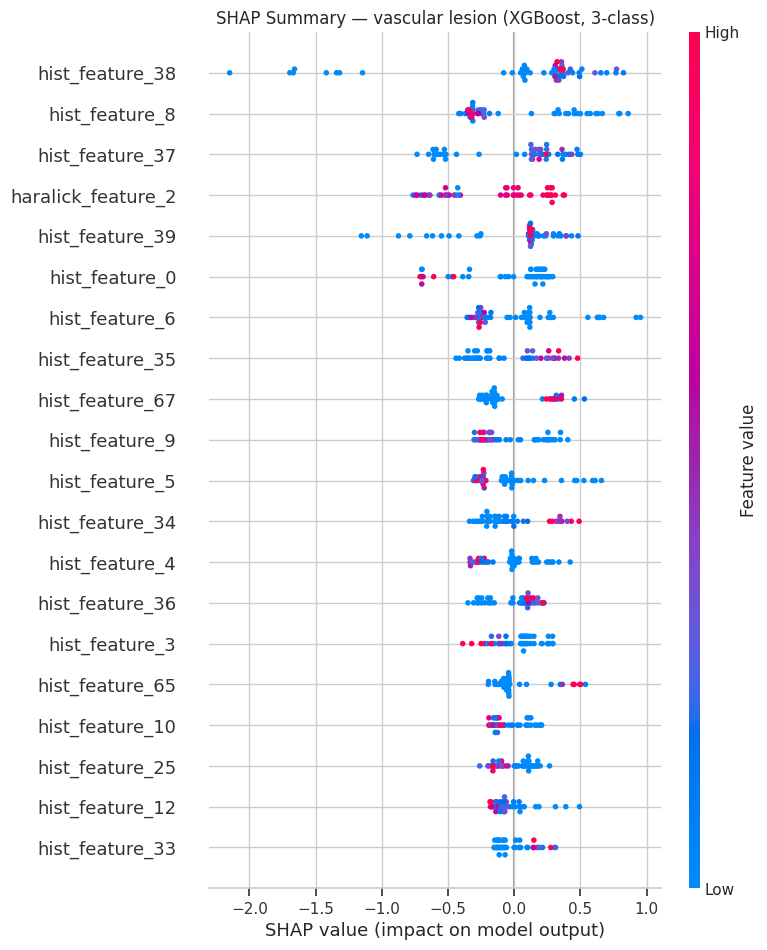

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_summary_0_vascular_lesion.png


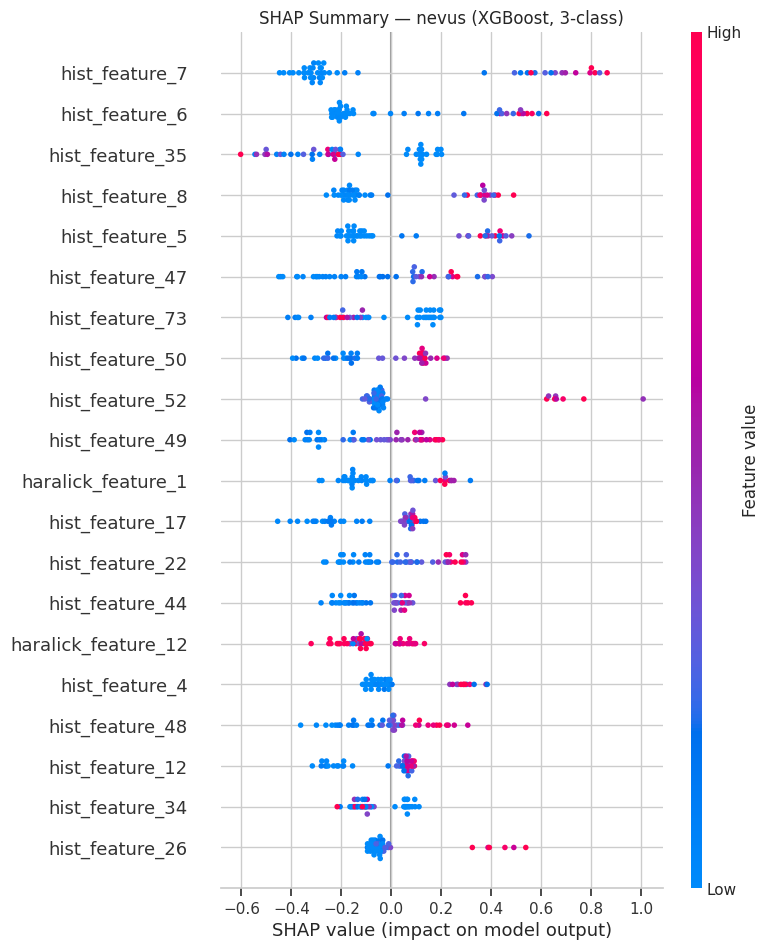

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_summary_1_nevus.png


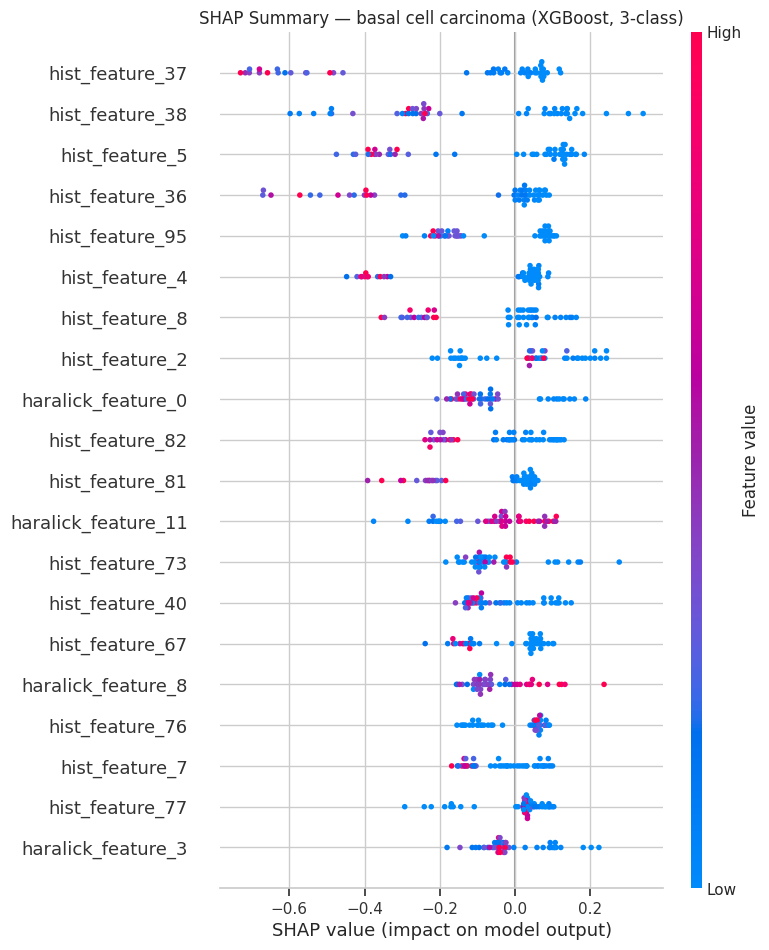

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_summary_2_basal_cell_carcinoma.png

Saved global SHAP ranking: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_global_importance.csv

Top 10 global SHAP features:


,feature,mean_abs_shap
41,hist_feature_38,0.273195
11,hist_feature_8,0.247720
40,hist_feature_37,0.218574
8,hist_feature_5,0.213211
10,hist_feature_7,0.203884
9,hist_feature_6,0.201757
38,hist_feature_35,0.176060
101,haralick_feature_2,0.143050
7,hist_feature_4,0.140172
42,hist_feature_39,0.132307


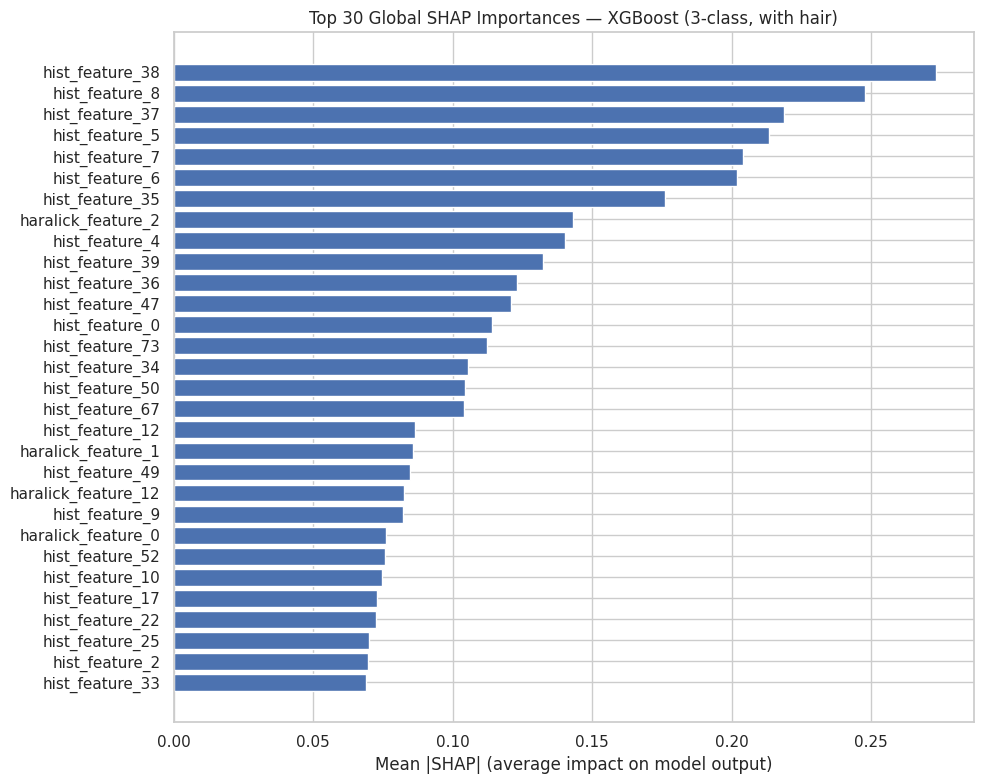

Saved global SHAP bar plot -> /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_global_top30.png


In [ ]:
# ====================== SHAP Fix — XGBoost (3-class, with hair) ======================

import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


#picking model + data
shap_model = best_model.named_steps["xgb"]

X_shap = X_test.copy()
y_shap = y_test.copy()

SHAP_DIR = os.path.join(RESULTS_DIR, "shap_xgb_3class")
os.makedirs(SHAP_DIR, exist_ok=True)

class_names = ["vascular lesion", "nevus", "basal cell carcinoma"]

print("Running SHAP on:")
print("X_shap shape:", X_shap.shape)
print("Unique y:", sorted(pd.Series(y_shap).unique()))


#computing SHAP (handling different SHAP versions)
explainer = shap.TreeExplainer(shap_model)

#newer SHAP prefers explainer(X) and returns an Explanation object
try:
    shap_exp = explainer(X_shap)
    print("\nGot SHAP Explanation object ")
    print("shap_exp.values shape:", shap_exp.values.shape)

    #multiclass -> (n_samples, n_features, n_classes)
    #binary -> (n_samples, n_features)
    shap_vals = shap_exp.values

except Exception as e:
    print("\nFalling back to explainer.shap_values(X) because:", str(e))
    shap_vals = explainer.shap_values(X_shap)
    print("Type:", type(shap_vals))


#normalizing to a clean multiclass format: list of [n_samples, n_features]

#Case A: Explanation values with shape (n_samples, n_features, n_classes)
if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    n_samples, n_features, n_classes = shap_vals.shape
    print("\nDetected multiclass SHAP array ")
    print("n_samples:", n_samples, "n_features:", n_features, "n_classes:", n_classes)

    shap_list = [shap_vals[:, :, i] for i in range(n_classes)]

#Case B: Explanation values with shape (n_samples, n_features) (binary)
elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 2:
    print("\nDetected binary/1-output SHAP array ")
    shap_list = [shap_vals]

#Case C: legacy shap_values(X) returns list already
elif isinstance(shap_vals, list):
    print("\nDetected legacy list-of-arrays ")
    shap_list = shap_vals

#Case D: something weird (like (n_features, n_classes) etc.)
else:
    raise ValueError(f"Unexpected SHAP format: type={type(shap_vals)}, ndim={getattr(shap_vals,'ndim',None)}")

#quick sanity check
print("\nFinal SHAP list lengths:", len(shap_list))
print("Each class SHAP shape:", shap_list[0].shape, "(should be n_samples x n_features)")

assert shap_list[0].shape[0] == X_shap.shape[0], "SHAP rows should match number of samples"
assert shap_list[0].shape[1] == X_shap.shape[1], "SHAP cols should match number of features"


#1) summary plots per class

# if shap_list length is 1, just plotting once
if len(shap_list) == 1:
    plt.figure()
    shap.summary_plot(shap_list[0], X_shap, show=False)
    plt.title("SHAP Summary — XGBoost")
    out_path = os.path.join(SHAP_DIR, "shap_summary.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

else:
    for i in range(min(3, len(shap_list))):
        plt.figure()
        shap.summary_plot(shap_list[i], X_shap, show=False)
        plt.title(f"SHAP Summary — {class_names[i]} (XGBoost, 3-class)")
        out_path = os.path.join(SHAP_DIR, f"shap_summary_{i}_{class_names[i].replace(' ','_')}.png")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)

#2) global importance: mean(|SHAP|) across classes

#average abs shap across classes first, then avg across samples
abs_shap_all = np.mean([np.abs(sv) for sv in shap_list], axis=0)  #(n_samples, n_features)
mean_abs_shap = abs_shap_all.mean(axis=0)                         #(n_features,)

shap_global_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

shap_csv_path = os.path.join(SHAP_DIR, "shap_global_importance.csv")
shap_global_df.to_csv(shap_csv_path, index=False)

print("\nSaved global SHAP ranking:", shap_csv_path)
print("\nTop 10 global SHAP features:")
display(shap_global_df.head(10))

#top 30 bar plot
top_n = 30
top_df = shap_global_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_df["feature"], top_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP| (average impact on model output)")
plt.title("Top 30 Global SHAP Importances — XGBoost (3-class, with hair)")
plt.tight_layout()

out_bar_path = os.path.join(SHAP_DIR, "shap_global_top30.png")
plt.savefig(out_bar_path, dpi=150)
plt.show()

print("Saved global SHAP bar plot ->", out_bar_path)

##SHAP: stacked HISTOGRAM for comparison

SHAP 3D shape: (48, 112, 3)


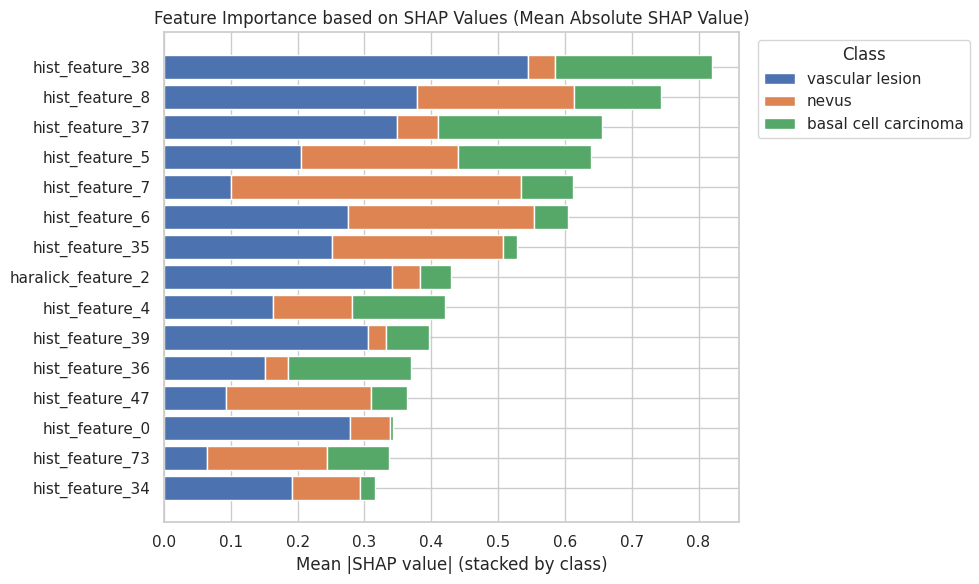

Saved stacked SHAP bar plot to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_stacked_bar_top15.png
Saved stacked SHAP table to: /content/drive/MyDrive/CAPSTONE PROJECT/plots_3class_with_hair/shap_xgb_3class/shap_stacked_bar_top15.csv


In [ ]:
# ====================== SHAP: stacked global importance ======================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NOTE:
# This makes a "stacked" bar chart:
#   - each feature gets one total bar (mean |SHAP|)
#   - the bar is split into 3 colored chunks (one per class)

# --- make sure these exist in your notebook ---
# SHAP_DIR = "/content/drive/MyDrive/.../shap_outputs_etc"
# X_shap = the dataframe / numpy array you used for SHAP (shape: n_samples x n_features)
# feature_names = list(X_shap.columns) if it's a df
# class_names = ["vascular lesion", "nevus", "basal cell carcinoma"]  (or whatever order your labels are)
# shap_values = the SHAP output you computed earlier

os.makedirs(SHAP_DIR, exist_ok=True)

# helper: convert SHAP output to a clean numpy array shaped (n_samples, n_features, n_classes)
def _to_shap_3d(shap_values, n_samples, n_features, n_classes):
    # case 1: shap returns a list of arrays, one per class
    if isinstance(shap_values, list):
        # expected: [ (n_samples, n_features), (n_samples, n_features), (n_samples, n_features) ]
        arr = np.stack(shap_values, axis=2)  # -> (n_samples, n_features, n_classes)
        return arr

    arr = np.array(shap_values)

    # common shapes:
    #  (n_samples, n_features, n_classes)
    #  (n_classes, n_samples, n_features)
    #  (n_features, n_classes)  <-- wrong / aggregated (not per-sample) so we can't plot properly

    if arr.ndim == 3:
        if arr.shape == (n_samples, n_features, n_classes):
            return arr
        if arr.shape == (n_classes, n_samples, n_features):
            return np.transpose(arr, (1, 2, 0))  # -> (n_samples, n_features, n_classes)

    raise ValueError(
        f"Unexpected SHAP shape: {arr.shape}. "
        f"I expected (n_samples,n_features,n_classes) or (n_classes,n_samples,n_features)."
    )

# get sizes + names
if hasattr(X_shap, "shape"):
    n_samples, n_features = X_shap.shape
else:
    X_shap = np.array(X_shap)
    n_samples, n_features = X_shap.shape

if "feature_names" not in globals() or feature_names is None:
    feature_names = X_shap.columns.tolist() if hasattr(X_shap, "columns") else [f"f{i}" for i in range(n_features)]

if "class_names" not in globals() or class_names is None:
    class_names = [f"class_{i}" for i in range(3)]

n_classes = len(class_names)

# convert shap output to (n_samples, n_features, n_classes)
shap_3d = _to_shap_3d(shap_values, n_samples, n_features, n_classes)

print("SHAP 3D shape:", shap_3d.shape)  # should be (n_samples, n_features, 3)

# mean absolute SHAP per feature per class -> (n_features, n_classes)
mean_abs = np.mean(np.abs(shap_3d), axis=0)

# total importance per feature (sum across classes)
total = mean_abs.sum(axis=1)

# pick top K features
TOP_K = 15  # change to 20/30 if you want
top_idx = np.argsort(total)[::-1][:TOP_K]

# build a plotting df (nice + easy)
plot_df = pd.DataFrame(mean_abs[top_idx, :], columns=class_names)
plot_df["feature"] = [feature_names[i] for i in top_idx]
plot_df["total"] = total[top_idx]

# reverse so biggest is at top in barh
plot_df = plot_df.sort_values("total", ascending=True).reset_index(drop=True)

# --- plot stacked horizontal bars ---
plt.figure(figsize=(10, 6))
left = np.zeros(len(plot_df))

for cname in class_names:
    plt.barh(plot_df["feature"], plot_df[cname], left=left, label=cname)
    left += plot_df[cname].values

plt.title("Feature Importance based on SHAP Values (Mean Absolute SHAP Value)")
plt.xlabel("Mean |SHAP value| (stacked by class)")
plt.ylabel("")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

out_path = os.path.join(SHAP_DIR, f"shap_stacked_bar_top{TOP_K}.png")
plt.savefig(out_path, dpi=150)
plt.show()

print("Saved stacked SHAP bar plot to:", out_path)

# also save the numbers (so you can cite in report)
csv_path = os.path.join(SHAP_DIR, f"shap_stacked_bar_top{TOP_K}.csv")
plot_df.to_csv(csv_path, index=False)
print("Saved stacked SHAP table to:", csv_path)
